# Eye-tracking vs Model Attention — Object-level Alignment

This notebook compares **human gaze** (from OGAMA fixation exports) against **model attention maps** from:
- a checkpoint **trained with gaze**, and
- a checkpoint **not trained with gaze** (baseline).

Goal: convert both gaze and model attention into **object-class distributions** using the OGAMA/segmentation masks, then compute statistics (histograms, confusion matrices, divergences, top-1 match, etc.).

---

## High-level pipeline

1. **Parse OGAMA** `stats_fixations.txt` for every respondent.
2. **Join** OGAMA trials to the comparisons dataframe via `(survey_id, trial_id)`.
3. **Build a color→object mapping** from OGAMA fixations sampled on each image’s `_seg.jpg` mask.
4. **Convert attention maps** → object distributions by summing attention mass per object mask.
5. **Compare** human vs models:
   - top-1 object match rate
   - per-object confusion matrices
   - distribution distances (JS divergence, L1)
   - per-object histograms and example visualizations


In [1]:

# Core
import os
import re
import glob
import json
import math
import random
from dataclasses import dataclass
from types import SimpleNamespace
from pathlib import Path
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd

# ML + vision
import torch
from torch.utils.data import DataLoader

from PIL import Image

# Stats / plots
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.spatial.distance import jensenshannon

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

SEED = 30
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

def pick_device(gpu_id: int = 0) -> torch.device:
    if torch.cuda.is_available() and torch.cuda.device_count() > gpu_id:
        return torch.device(f"cuda:{gpu_id}")
    return torch.device("cpu")

DEVICE = pick_device(gpu_id=0)
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(DEVICE))

from pathlib import Path
import json
import re
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
from PIL import Image

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    from transformers import AutoImageProcessor, SegformerForSemanticSegmentation
except ImportError as e:
    raise ImportError(
        "Missing dependency: transformers. Install it in the active environment before running this cell."
    ) from e


DEVICE: cuda:0
GPU: NVIDIA GeForce GTX 1080 Ti


/home/csantiago/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0) Configuration

Edit paths/constants here if needed. The defaults match the project layout described.

In [2]:

# -------------------------------
# Paths (project defaults)
# -------------------------------
REPO_ROOT = Path("/home/csantiago").resolve()

TRAIN_PKL = Path("/home/csantiago/splits/comparisons_df_train.pkl")
VAL_PKL   = Path("/home/csantiago/splits/comparisons_df_val.pkl")
TEST_PKL  = Path("/home/csantiago/splits/comparisons_df_test.pkl")

DATASET_ROOT = Path("/home/csantiago/images/printart/subjectivesafety_images/").resolve()
OGAMA_ROOT   = Path("/home/csantiago/survey_eye_tracker/eye_tracker_data").resolve()

# W&B + checkpoints cache (local)
WANDB_DIR = Path("/home/csantiago/wandb").resolve()
MODEL_DIR = Path("/home/csantiago/models").resolve()

# Analysis output folder
OUT_DIR = Path("./outputs_eye_vs_model").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------
# Screen / stimulus geometry (for mapping OGAMA coordinates to per-image coordinates)
# -------------------------------
# Default: two images shown side-by-side, each 864x508, no gap.
# Screen resolution
SCREEN_W = 1920
SCREEN_H = 1200

# Displayed image size
DISPLAY_SINGLE_W = 864
DISPLAY_SINGLE_H = 508

# Screen positions of each image
LEFT_X_OFFSET  = 76
LEFT_Y_OFFSET  = 225

RIGHT_X_OFFSET = 979
RIGHT_Y_OFFSET = 225

# Optional derived gap
DISPLAY_GAP_X = RIGHT_X_OFFSET - (LEFT_X_OFFSET + DISPLAY_SINGLE_W)   # 39

# -------------------------------
# Evaluation split
# -------------------------------
EVAL_SPLIT = "test"   # "val" or "test"

# Filter: only trials with eyetracker in dataframe
ONLY_EYETRACKER_ROWS = True

# -------------------------------
# Respondent folders (relative to OGAMA_ROOT)
# -------------------------------
USERS = [
    "cycling932844b29e6175a85d195cbee96ce34057d0b2cb0b9bb90018e0301ef2460b82/2022_10_10_12_39_43",
    "cycling132c5e4c5b0a45e274e7fb849fecd22e62edf409bd5f1b1322ddeb6d11f90d7d/2022_10_10_13_21_15",
    "cycling0a3df224a10f3472c2a9c568a927406a49b012186f0983b9e10bcd883b4d5fcd/2022_10_18_14_08_36",
    "cyclingbd1af6d2f4bda83c3d5d6dfc93817421d804a644ab12251d1033c885730217a4/2022_11_02_15_30_21",
    "cycling28b744c8c0b8b330c7f678d5b23aa2ce614a5ae8143e96173fe3cde26ec2297e/2022_11_28_09_08_48",
    "cycling145b3ad29cb766fb22e4cfba1d750db8c17470b8d07a6f01aad5918e20ccbe80/2022_11_29_09_51_39",
    "cycling5876966995d4b61ed7073ec1ea1a92e1d3bcfbb02705d2bb441819922aaa89db/2022_11_29_10_23_22",
    "cycling4eea1bbed89e15ea4b3ecbc10b941272711810e0f2648161ece9d5bcb9839dba/2022_11_29_10_56_24",
    "cycling8ffc01ebc87eb6aa9285e7688c79a4a6b63cf21a119820f13f054cd0e2fdd987/2022_11_29_13_54_31",
    "cycling7e8315cff8453c95082b56e5b4745609cfda7bddd20bbc92c8f3f88dea3fd715/2022_12_01_09_09_42",
    "cycling5e970a9dfb4a47cae2526d10a49e351fa97d26d6e24798cddf9e8ad77f6379fc/2022_12_01_09_52_46",
    "cyclingd22a19aa45e85ca027d29be0fe3b839383d8566f1997284a96d2f97b8b5b9e63/2022_12_01_10_23_11",
    "cycling684fdee4e2ba556e4e23a3f68062835cf9796cec92ffdbe9ce53171345f32e7b/2022_12_01_10_46_42",
    "cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc3836a99e1333cd536cd9b1bdd/2022_12_02_09_46_55",
    "cyclingc08377f1e6826ffd8f74f4e1515d85319a2705749e0bb560f47e2e9c5c48186d/2022_12_02_10_18_23",
    "cyclingdbdde36bbe3344b160d31a87c5d85169c36650245f3d312494627ff1464bb2e4/2022_12_02_12_53_18",
    "cycling5aa98a95dbd30e4ffd9d5f18d19cc095f093954581f2842e9daed80395793b90/2022_12_02_13_25_43",
    "cyclingad8bc642880020eb31d2c1d5d10857bc864a01936bb335fe7a30e584ab21ebf8/2022_12_02_13_53_36",
    "cycling469572b0c7fe5cc0c5f020ebae513ffeae62ec445e8b5c19154ba2e3ee1f6de4/2022_12_05_09_46_56",
    "cycling61e4dc72e3a5c92061a3b8c78ea0f11334dcab587b2abebe99315c92213be055/2022_12_05_12_39_03",
    "cycling4c845f8ebd5f514f1fdc690d2ab60d5f8beb818b464cea0fe96ca4f97a4f773e/2022_12_08_09_19_45",
    "cycling2846319a17ec7fcad28ab540e7a7b18c9432e63357a06e9d15630eeb1ae62be3/2022_12_08_13_20_21",
]

assert OGAMA_ROOT.exists(), f"OGAMA_ROOT missing: {OGAMA_ROOT}"
assert DATASET_ROOT.exists(), f"DATASET_ROOT missing: {DATASET_ROOT}"
print("Configured OK.")


Configured OK.


## 1) Load comparisons dataframe split and verify the keys

Required columns: `['score','image_l','image_r','dataset','has_eyetracker','npy_file_l','npy_file_r','survey_id','trial_id']`

In [3]:

def load_split_df(split: str) -> pd.DataFrame:
    split = str(split).lower().strip()
    p = {"train": TRAIN_PKL, "val": VAL_PKL, "test": TEST_PKL}.get(split, TEST_PKL)
    if not Path(p).exists():
        raise FileNotFoundError(f"Missing split pickle: {p}")
    return pd.read_pickle(p)

train_df = load_split_df("train")
val_df   = load_split_df("val")
test_df  = load_split_df("test")

df_eval = val_df if EVAL_SPLIT == "val" else test_df
print("Split:", EVAL_SPLIT, "rows:", len(df_eval), "| train rows:", len(train_df))

required_cols = ['score', 'image_l', 'image_r', 'dataset', 'has_eyetracker',
                 'npy_file_l', 'npy_file_r', 'survey_id', 'trial_id']
missing_cols = [c for c in required_cols if c not in df_eval.columns]
if missing_cols:
    raise KeyError(f"df_eval missing columns: {missing_cols}")

df_eval_use = df_eval.copy()
if ONLY_EYETRACKER_ROWS:
    df_eval_use = df_eval_use[df_eval_use["has_eyetracker"].astype(bool)].copy()

df_eval_use["survey_id"] = df_eval_use["survey_id"].astype(str).str.strip()
df_eval_use["trial_id"]  = df_eval_use["trial_id"].astype(int)

print("Eval rows used:", len(df_eval_use))
df_eval_use.head()


Split: test rows: 1182 | train rows: 4134
Eval rows used: 162


,score,image_l,image_r,dataset,has_eyetracker,npy_file_l,npy_file_r,survey_id,trial_id,score_classification
12354,-1,7117.jpg,8961.jpg,berlin,True,surveycyclingbd1af6d2f4bda83c3d5d6dfc93817421d...,surveycyclingbd1af6d2f4bda83c3d5d6dfc93817421d...,cyclingbd1af6d2f4bda83c3d5d6dfc93817421d804a64...,32,0
12610,-1,3152.jpg,10183.jpg,berlin,True,surveycycling4eea1bbed89e15ea4b3ecbc10b9412727...,surveycycling4eea1bbed89e15ea4b3ecbc10b9412727...,cycling4eea1bbed89e15ea4b3ecbc10b941272711810e...,28,0
13288,1,3010.jpg,10147.jpg,berlin,True,surveycyclingad8bc642880020eb31d2c1d5d10857bc8...,surveycyclingad8bc642880020eb31d2c1d5d10857bc8...,cyclingad8bc642880020eb31d2c1d5d10857bc864a019...,56,1
12784,-1,859.jpg,1756.jpg,berlin,True,surveycycling5e970a9dfb4a47cae2526d10a49e351fa...,surveycycling5e970a9dfb4a47cae2526d10a49e351fa...,cycling5e970a9dfb4a47cae2526d10a49e351fa97d26d...,7,0
13380,1,3235.jpg,3668.jpg,berlin,True,surveycycling61e4dc72e3a5c92061a3b8c78ea0f1133...,surveycycling61e4dc72e3a5c92061a3b8c78ea0f1133...,cycling61e4dc72e3a5c92061a3b8c78ea0f11334dcab5...,18,1


## 2) Parse OGAMA `stats_fixations.txt`

For each respondent folder:
- `survey_id` = first path segment (e.g. `cycling...`)
- `trial_id`  = OGAMA `TrialID`
- `object`    = OGAMA `AOI group` (fallback to `AOI` when missing)

Coordinates are preserved for optional mask sampling, but analysis uses object labels.


In [4]:

def parse_stats_fixations_txt(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing OGAMA file: {path}")

    df = pd.read_csv(
        path,
        sep="\t",
        comment="#",
        engine="python",
        dtype=str,
        keep_default_na=False,
    )

    df.columns = [str(c).strip() for c in df.columns]

    col_map = {
        "SubjectName": "subject_name",
        "TrialID": "trial_id",
        "StartTime": "start_time",
        "Length": "duration",
        "PosX": "pos_x",
        "PosY": "pos_y",
        "AOI": "aoi",
        "AOI group": "aoi_group",
    }

    out = {}
    for src, dst in col_map.items():
        out[dst] = df[src] if src in df.columns else ""

    dfo = pd.DataFrame(out)

    dfo["trial_id"] = pd.to_numeric(dfo["trial_id"], errors="coerce").fillna(-1).astype(int)
    dfo["duration"] = pd.to_numeric(dfo["duration"], errors="coerce").fillna(0.0).astype(float)
    dfo["pos_x"] = pd.to_numeric(dfo["pos_x"], errors="coerce").fillna(np.nan).astype(float)
    dfo["pos_y"] = pd.to_numeric(dfo["pos_y"], errors="coerce").fillna(np.nan).astype(float)

    for c in ["aoi", "aoi_group", "subject_name"]:
        dfo[c] = dfo[c].astype(str).str.strip()

    dfo["object"] = dfo["aoi_group"]
    dfo.loc[dfo["object"].eq("") | dfo["object"].isna(), "object"] = dfo["aoi"]
    dfo["object"] = dfo["object"].astype(str).str.strip()
    dfo.loc[dfo["object"].eq(""), "object"] = "unknown"

    return dfo

def infer_side_from_aoi(aoi: str) -> Optional[str]:
    s = str(aoi).lower().strip()
    if "left" in s:
        return "l"
    if "right" in s:
        return "r"
    return None

def load_all_ogama_fixations(users: List[str], ogama_root: Path) -> pd.DataFrame:
    rows = []
    for rel in users:
        rel = str(rel).strip().strip("/")
        survey_id = rel.split("/")[0]
        base = ogama_root / rel
        fx_path = base / "stats_fixations.txt"
        if not fx_path.exists():
            print(f"[WARN] Missing stats_fixations.txt for: {rel}")
            continue

        df = parse_stats_fixations_txt(fx_path)
        df["survey_id"] = survey_id
        df["respondent_relpath"] = rel
        df["side"] = df["aoi"].apply(infer_side_from_aoi)

        rows.append(df)

    if not rows:
        raise RuntimeError("No OGAMA fixation files were found/parsed.")
    return pd.concat(rows, ignore_index=True)

df_fix = load_all_ogama_fixations(USERS, OGAMA_ROOT)
print("Parsed fixations:", len(df_fix))
df_fix.head()


[WARN] Missing stats_fixations.txt for: cycling61e4dc72e3a5c92061a3b8c78ea0f11334dcab587b2abebe99315c92213be055/2022_12_05_12_39_03
[WARN] Missing stats_fixations.txt for: cycling2846319a17ec7fcad28ab540e7a7b18c9432e63357a06e9d15630eeb1ae62be3/2022_12_08_13_20_21
Parsed fixations: 30943


,subject_name,trial_id,start_time,duration,pos_x,pos_y,aoi,aoi_group,object,survey_id,respondent_relpath,side
0,a1ef2460b82,1,0,6.0,1505.804565,413.497192,imagerightbuildingbf,building,building,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,r
1,a1ef2460b82,1,35,222.0,1530.444336,929.806091,nowhere,nowhere,nowhere,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,None
2,a1ef2460b82,1,314,199.0,1100.390747,441.205231,imagerighttruckel,truck,truck,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,r
3,a1ef2460b82,1,558,199.0,602.100586,406.335388,imageleftbuildingy,building,building,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,l
4,a1ef2460b82,1,801,403.0,583.282837,506.071198,imageleftsidewalkp,sidewalk,sidewalk,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,l


## 3) Human gaze → object distributions per trial and side

Aggregates both `count` and `duration` per `(survey_id, trial_id, side, object)`.
Produces a per-trial normalized distribution over object labels.


In [5]:

def build_human_object_stats(df_fix: pd.DataFrame) -> pd.DataFrame:
    df = df_fix.copy()
    df = df[df["trial_id"] >= 0].copy()
    df["side"] = df["side"].fillna("unknown")

    g = (
        df.groupby(["survey_id", "trial_id", "side", "object"], as_index=False)
          .agg(count=("object", "size"), duration=("duration", "sum"))
    )
    return g

human_obj = build_human_object_stats(df_fix)

# Save per respondent ID (survey_id)
out_human_dir = OUT_DIR / "ogama_human_objects"
out_human_dir.mkdir(parents=True, exist_ok=True)

for sid, sdf in human_obj.groupby("survey_id"):
    sdf.sort_values(["trial_id","side","duration"], ascending=[True, True, False]) \
       .to_csv(out_human_dir / f"{sid}_human_objects_by_trial.csv", index=False)

print("Saved per-survey OGAMA object summaries to:", out_human_dir)
human_obj.head()


Saved per-survey OGAMA object summaries to: /home/csantiago/Analysis/outputs_eye_vs_model/ogama_human_objects


,survey_id,trial_id,side,object,count,duration
0,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,1,l,road,6,1024.0
1,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,1,r,road,5,1037.0
2,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,1,r,sidewalk,1,158.0
3,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,1,unknown,nowhere,3,335.0
4,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,2,l,road,1,455.0


## 4) Join OGAMA to comparisons dataframe by `(survey_id, trial_id)`

This step links fixations to the exact image pair shown in the comparison dataset.


In [6]:

ogama_keys = set(zip(human_obj["survey_id"].astype(str), human_obj["trial_id"].astype(int)))
df_keys    = set(zip(df_eval_use["survey_id"].astype(str), df_eval_use["trial_id"].astype(int)))

print("Unique OGAMA (survey_id,trial_id):", len(ogama_keys))
print("Unique DF   (survey_id,trial_id):", len(df_keys))
print("Intersection:", len(ogama_keys & df_keys))
print("OGAMA-only:", len(ogama_keys - df_keys))
print("DF-only:", len(df_keys - ogama_keys))

df_eval_matched = df_eval_use[df_eval_use.apply(lambda r: (str(r["survey_id"]), int(r["trial_id"])) in ogama_keys, axis=1)].copy()
print("Matched eval rows:", len(df_eval_matched))

def human_trial_side_distribution(human_obj_long: pd.DataFrame, weight_col: str = "duration") -> pd.DataFrame:
    df = human_obj_long.copy()
    df = df[df["side"].isin(["l","r"])].copy()
    df["w"] = df[weight_col].astype(float)
    denom = df.groupby(["survey_id","trial_id","side"])["w"].transform("sum").replace(0, np.nan)
    df["p"] = (df["w"] / denom).fillna(0.0)
    return df[["survey_id","trial_id","side","object","p","w"]]

human_dist = human_trial_side_distribution(human_obj, weight_col="duration")
human_dist.head()


Unique OGAMA (survey_id,trial_id): 1300
Unique DF   (survey_id,trial_id): 162
Intersection: 139
OGAMA-only: 1161
DF-only: 23
Matched eval rows: 139


,survey_id,trial_id,side,object,p,w
0,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,1,l,road,1.000000,1024.0
1,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,1,r,road,0.867782,1037.0
2,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,1,r,sidewalk,0.132218,158.0
4,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,2,l,road,0.113043,455.0
5,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,2,l,sky,0.637516,2566.0


## 5) Segmentation masks and color→object mapping

Assumption: each original image has a corresponding segmentation mask `*_seg.jpg` next to it.

Each `_seg.jpg` is a color-coded AOI/segmentation image.  
A mapping from `RGB → object label` is derived by sampling the segmentation color at OGAMA fixation coordinates.

Notes:
- OGAMA positions are in screen coordinates (two images side-by-side).
- Side is inferred from the AOI name (`imageleft...` / `imageright...`).
- Screen X is converted to per-image X by subtracting `RIGHT_X_OFFSET` for right side.


In [7]:
# This cell:
# 1. Creates semantic segmentation masks (*_seg.png) for images that do not yet have them.
# 2. Uses OGAMA fixations to learn an RGB -> object mapping from those masks.
#
# Important:
# - Segmentation masks are saved as PNG because JPEG is lossy and can corrupt exact RGB values.
# - build_seg_path() looks for *_seg.png first and falls back to *_seg.jpg only if needed.
# - The RGB -> object mapping is learned from human fixations, so only fixated colors become mapped.

# ------------------------------------------------------------
# Segmentation configuration
# ------------------------------------------------------------
SEG_MODEL_NAME = "nvidia/segformer-b5-finetuned-cityscapes-1024-1024"

# Which splits to segment before building the RGB -> object mapping
SEGMENT_SPLITS = ("test",)   # or ("test",)

SEG_BATCH_SIZE = 4
SEG_OVERWRITE_EXISTING = False
SEG_WRITE_PREVIEW_JPG = False   # preview only
SEG_SAVE_ID_MASK = True
SEG_DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

SEG_SCHEMA_PATH = OUT_DIR / "street_segmentation_schema_cityscapes.json"
SEG_LOG_PATH = OUT_DIR / "segmentation_generation_log.csv"


# ------------------------------------------------------------
# Helper paths
# ------------------------------------------------------------
def build_image_path_from_row(row: pd.Series, side: str) -> Path:
    city = str(row["dataset"]).strip() if ("dataset" in row.index and pd.notna(row["dataset"])) else ""
    img_col = "image_l" if side == "l" else "image_r"
    img_name = str(row[img_col]).strip()
    if city:
        return DATASET_ROOT / city / img_name
    return DATASET_ROOT / img_name


def build_seg_png_path(img_path: Path) -> Path:
    stem = re.sub(r"(?i)\.(jpg|jpeg|png)$", "", str(img_path))
    return Path(stem + "_seg.png")


def build_seg_jpg_preview_path(img_path: Path) -> Path:
    stem = re.sub(r"(?i)\.(jpg|jpeg|png)$", "", str(img_path))
    return Path(stem + "_seg.jpg")


def build_seg_id_path(img_path: Path) -> Path:
    stem = re.sub(r"(?i)\.(jpg|jpeg|png)$", "", str(img_path))
    return Path(stem + "_seg_id.png")


def build_seg_path(img_path: Path) -> Path:
    stem = re.sub(r"(?i)\.(jpg|jpeg|png)$", "", str(img_path))
    seg_png = Path(stem + "_seg.png")
    if seg_png.exists():
        return seg_png
    return Path(stem + "_seg.jpg")


def safe_load_rgb(path: Path) -> np.ndarray:
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)


def clamp_int(v: float, lo: int, hi: int) -> int:
    if not np.isfinite(v):
        return lo
    return int(max(lo, min(hi, int(round(v)))))


# ------------------------------------------------------------
# Cityscapes semantic palette
# ------------------------------------------------------------
CITYSCAPES_COLOR_BY_NAME = {
    "road": (128, 64, 128),
    "sidewalk": (244, 35, 232),
    "building": (70, 70, 70),
    "wall": (102, 102, 156),
    "fence": (190, 153, 153),
    "pole": (153, 153, 153),
    "traffic light": (250, 170, 30),
    "traffic sign": (220, 220, 0),
    "vegetation": (107, 142, 35),
    "terrain": (152, 251, 152),
    "sky": (70, 130, 180),
    "person": (220, 20, 60),
    "rider": (255, 0, 0),
    "car": (0, 0, 142),
    "truck": (0, 0, 70),
    "bus": (0, 60, 100),
    "train": (0, 80, 100),
    "motorcycle": (0, 0, 230),
    "bicycle": (119, 11, 32),
}


def normalize_label_name(name: str) -> str:
    s = str(name).strip().lower()
    s = s.replace("_", " ").replace("-", " ")
    s = re.sub(r"\s+", " ", s)
    return s


def fallback_color(label_id: int) -> Tuple[int, int, int]:
    rng = np.random.default_rng(int(label_id) + 12345)
    color = rng.integers(0, 256, size=3, dtype=np.uint8)
    return int(color[0]), int(color[1]), int(color[2])


def build_palette_from_model_id2label(id2label: Dict[int, str]) -> Dict[int, Tuple[int, int, int]]:
    palette = {}
    for label_id, label_name in id2label.items():
        key = normalize_label_name(label_name)
        palette[int(label_id)] = CITYSCAPES_COLOR_BY_NAME.get(key, fallback_color(int(label_id)))
    return palette


def decode_label_map_to_rgb(
    label_map: np.ndarray,
    palette: Dict[int, Tuple[int, int, int]],
) -> np.ndarray:
    h, w = label_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for label_id in np.unique(label_map):
        rgb[label_map == int(label_id)] = palette[int(label_id)]
    return rgb


def save_global_segmentation_schema(
    schema_path: Path,
    model_name: str,
    id2label: Dict[int, str],
    palette: Dict[int, Tuple[int, int, int]],
) -> None:
    schema = {
        "model_name": model_name,
        "id2label": {int(k): str(v) for k, v in id2label.items()},
        "palette": {int(k): list(map(int, v)) for k, v in palette.items()},
    }
    with open(schema_path, "w", encoding="utf-8") as f:
        json.dump(schema, f, indent=2)


# ------------------------------------------------------------
# Collect images to segment
# ------------------------------------------------------------
def collect_unique_image_paths_from_splits(
    split_names: Tuple[str, ...]
) -> List[Path]:
    split_map = {
        "train": train_df,
        "val": val_df,
        "test": test_df,
        "eval": df_eval_use,
    }

    paths = set()
    for split_name in split_names:
        split_name = str(split_name).strip().lower()
        if split_name not in split_map:
            raise ValueError(f"Unknown split name: {split_name}")

        df_src = split_map[split_name]
        for _, row in df_src.iterrows():
            for side in ("l", "r"):
                img_path = build_image_path_from_row(row, side)
                if img_path.exists():
                    paths.add(str(img_path))

    return [Path(p) for p in sorted(paths)]


# ------------------------------------------------------------
# Segmentation generation
# ------------------------------------------------------------
def segment_missing_images(
    image_paths: List[Path],
    model_name: str,
    batch_size: int,
    device: torch.device,
    overwrite: bool = False,
    write_preview_jpg: bool = False,
    save_id_mask: bool = True,
) -> pd.DataFrame:
    image_paths = [Path(p) for p in image_paths]

    pending = []
    already_done = 0
    missing_inputs = 0

    for img_path in image_paths:
        seg_png = build_seg_png_path(img_path)
        if not img_path.exists():
            missing_inputs += 1
            continue
        if seg_png.exists() and not overwrite:
            already_done += 1
            continue
        pending.append(img_path)

    print(f"Images discovered: {len(image_paths)}")
    print(f"Already segmented: {already_done}")
    print(f"Missing source images: {missing_inputs}")
    print(f"Queued for segmentation: {len(pending)}")

    if len(pending) == 0:
        return pd.DataFrame(columns=["image_path", "seg_png", "seg_jpg_preview", "seg_id_png"])

    processor = AutoImageProcessor.from_pretrained(model_name, use_fast=False)
    model = SegformerForSemanticSegmentation.from_pretrained(
        model_name,
        use_safetensors=True,
    ).to(device)
    model.eval()

    id2label_raw = getattr(model.config, "id2label", {}) or {}
    id2label = {int(k): str(v) for k, v in id2label_raw.items()}
    palette = build_palette_from_model_id2label(id2label)

    save_global_segmentation_schema(SEG_SCHEMA_PATH, model_name, id2label, palette)
    print("Saved schema:", SEG_SCHEMA_PATH)

    records = []

    for start in tqdm(range(0, len(pending), batch_size), desc="Segmenting"):
        batch_paths = pending[start:start + batch_size]

        pil_images = []
        target_sizes = []
        valid_paths = []

        for img_path in batch_paths:
            try:
                img = Image.open(img_path).convert("RGB")
                pil_images.append(img)
                target_sizes.append((img.height, img.width))
                valid_paths.append(img_path)
            except Exception as ex:
                print(f"[WARN] Failed to open image: {img_path} | {ex}")

        if len(valid_paths) == 0:
            continue

        inputs = processor(images=pil_images, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        seg_maps = processor.post_process_semantic_segmentation(
            outputs,
            target_sizes=target_sizes
        )

        for img_path, seg_tensor in zip(valid_paths, seg_maps):
            seg_ids = seg_tensor.detach().cpu().numpy().astype(np.uint8)
            seg_rgb = decode_label_map_to_rgb(seg_ids, palette)

            seg_png_path = build_seg_png_path(img_path)
            seg_png_path.parent.mkdir(parents=True, exist_ok=True)
            Image.fromarray(seg_rgb).save(seg_png_path, format="PNG")

            seg_jpg_path = None
            if write_preview_jpg:
                seg_jpg_path = build_seg_jpg_preview_path(img_path)
                Image.fromarray(seg_rgb).save(seg_jpg_path, format="JPEG", quality=100, subsampling=0)

            seg_id_path = None
            if save_id_mask:
                seg_id_path = build_seg_id_path(img_path)
                Image.fromarray(seg_ids, mode="L").save(seg_id_path, format="PNG")

            label_ids, counts = np.unique(seg_ids, return_counts=True)
            label_hist = {
                str(int(label_id)): int(count)
                for label_id, count in zip(label_ids.tolist(), counts.tolist())
            }

            records.append({
                "image_path": str(img_path),
                "seg_png": str(seg_png_path),
                "seg_jpg_preview": str(seg_jpg_path) if seg_jpg_path is not None else None,
                "seg_id_png": str(seg_id_path) if seg_id_path is not None else None,
                "label_hist": label_hist,
            })

    return pd.DataFrame(records)


# ------------------------------------------------------------
# OGAMA fixation -> image coordinates
# ------------------------------------------------------------
df_row_by_key: Dict[Tuple[str, int], pd.Series] = {}
for _, r in df_eval_use.iterrows():
    k = (str(r["survey_id"]).strip(), int(r["trial_id"]))
    if k not in df_row_by_key:
        df_row_by_key[k] = r


def fixation_to_image_xy(row_fix: pd.Series) -> Optional[Tuple[str, float, float]]:
    side = row_fix.get("side", None)
    if side not in ("l", "r"):
        return None

    x = float(row_fix["pos_x"])
    y = float(row_fix["pos_y"])

    if side == "l":
        x = x - float(LEFT_X_OFFSET)
        y = y - float(LEFT_Y_OFFSET)
    else:
        x = x - float(RIGHT_X_OFFSET)
        y = y - float(RIGHT_Y_OFFSET)

    return (side, x, y)


# ------------------------------------------------------------
# Learn RGB -> object mapping from OGAMA fixations
# ------------------------------------------------------------
def build_color_to_object_mapping(
    df_fix: pd.DataFrame,
    df_row_by_key: Dict[Tuple[str, int], pd.Series],
    max_fixations: Optional[int] = 200_000,
    min_votes_per_color: int = 20,
) -> Dict[Tuple[int, int, int], str]:
    df = df_fix.copy()
    df = df[(df["trial_id"] >= 0) & df["side"].isin(["l", "r"])].copy()
    df = df[~df["object"].astype(str).str.lower().isin(["nowhere", "unknown", ""])].copy()

    if max_fixations is not None and len(df) > max_fixations:
        df = df.sample(n=int(max_fixations), random_state=SEED).copy()

    votes: Dict[Tuple[int, int, int], Dict[str, int]] = {}
    n_used = 0
    n_missing = 0

    for _, fx in df.iterrows():
        k = (str(fx["survey_id"]).strip(), int(fx["trial_id"]))
        if k not in df_row_by_key:
            continue

        xy = fixation_to_image_xy(fx)
        if xy is None:
            continue

        side, x_img, y_img = xy

        if not (0 <= x_img < DISPLAY_SINGLE_W and 0 <= y_img < DISPLAY_SINGLE_H):
            continue

        row = df_row_by_key[k]
        img_path = build_image_path_from_row(row, side)
        seg_path = build_seg_path(img_path)

        if not seg_path.exists():
            n_missing += 1
            continue

        seg = safe_load_rgb(seg_path)
        h, w, _ = seg.shape

        x_scaled = (x_img / float(DISPLAY_SINGLE_W)) * float(w)
        y_scaled = (y_img / float(DISPLAY_SINGLE_H)) * float(h)

        xi = clamp_int(x_scaled, 0, w - 1)
        yi = clamp_int(y_scaled, 0, h - 1)

        rgb = tuple(int(c) for c in seg[yi, xi, :].tolist())
        obj = str(fx["object"]).strip().lower()

        if rgb not in votes:
            votes[rgb] = {}
        votes[rgb][obj] = votes[rgb].get(obj, 0) + 1
        n_used += 1

    color_to_obj: Dict[Tuple[int, int, int], str] = {}
    for rgb, d in votes.items():
        total = sum(d.values())
        if total < int(min_votes_per_color):
            continue
        best = sorted(d.items(), key=lambda kv: kv[1], reverse=True)[0][0]
        color_to_obj[rgb] = best

    print("Fixations used for mapping:", n_used)
    print("Fixations skipped (missing seg mask):", n_missing)
    print("Mapped colors (after min votes):", len(color_to_obj))
    return color_to_obj


# ------------------------------------------------------------
# Run segmentation first
# ------------------------------------------------------------
all_image_paths = collect_unique_image_paths_from_splits(SEGMENT_SPLITS)

df_segmented = segment_missing_images(
    image_paths=all_image_paths,
    model_name=SEG_MODEL_NAME,
    batch_size=SEG_BATCH_SIZE,
    device=SEG_DEVICE,
    overwrite=SEG_OVERWRITE_EXISTING,
    write_preview_jpg=SEG_WRITE_PREVIEW_JPG,
    save_id_mask=SEG_SAVE_ID_MASK,
)

df_segmented.to_csv(SEG_LOG_PATH, index=False)
print("Saved segmentation log:", SEG_LOG_PATH)

# ------------------------------------------------------------
# Then build RGB -> object mapping
# ------------------------------------------------------------
color_to_object = build_color_to_object_mapping(
    df_fix,
    df_row_by_key,
    max_fixations=250_000,
    min_votes_per_color=0,
)

map_path = OUT_DIR / "color_to_object.json"
with open(map_path, "w", encoding="utf-8") as f:
    json.dump({f"{k[0]},{k[1]},{k[2]}": v for k, v in color_to_object.items()}, f, indent=2)

print("Saved:", map_path)


df_map = pd.DataFrame(
    [(k, v) for k, v in color_to_object.items()],
    columns=["rgb", "object"]
).sort_values("object")

print("Segmented images created in this run:", len(df_segmented))
df_map.head(20)

Images discovered: 1867
Already segmented: 1867
Missing source images: 0
Queued for segmentation: 0
Saved segmentation log: /home/csantiago/Analysis/outputs_eye_vs_model/segmentation_generation_log.csv
Fixations used for mapping: 3029
Fixations skipped (missing seg mask): 0
Mapped colors (after min votes): 19
Saved: /home/csantiago/Analysis/outputs_eye_vs_model/color_to_object.json
Segmented images created in this run: 0


,rgb,object
9,"(220, 220, 0)",road
1,"(0, 0, 142)",road
2,"(128, 64, 128)",road
3,"(244, 35, 232)",road
5,"(0, 60, 100)",road
6,"(0, 0, 70)",road
7,"(255, 0, 0)",road
8,"(152, 251, 152)",road
17,"(119, 11, 32)",road
10,"(102, 102, 156)",road


### Build per-image label grid at ViT attention resolution

To compare model attention (`gh×gw`) with objects, the segmentation mask is converted to a label grid:
- Load `_seg.jpg` as RGB
- Map each RGB pixel to an object label using `color_to_object`
- Resize (nearest) to `(gw, gh)` and use that grid for attention aggregation


In [8]:
# ------------------------------------------------------------
# Load segmentation schema from section 5
# ------------------------------------------------------------
with open(SEG_SCHEMA_PATH, "r", encoding="utf-8") as f:
    SEG_SCHEMA = json.load(f)

SEG_ID2LABEL = {int(k): str(v).strip().lower() for k, v in SEG_SCHEMA["id2label"].items()}
SEG_PALETTE = {int(k): tuple(v) for k, v in SEG_SCHEMA["palette"].items()}
SEG_RGB2ID = {tuple(v): int(k) for k, v in SEG_SCHEMA["palette"].items()}


# ------------------------------------------------------------
# Harmonize OGAMA labels into segmentation vocabulary
# Expand this mapping if OGAMA contains additional labels.
# ------------------------------------------------------------
OGAMA_TO_SEMANTIC = {
    "road": "road",
    "sidewalk": "sidewalk",
    "building": "building",
    "wall": "wall",
    "fence": "fence",
    "pole": "pole",
    "traffic sign": "traffic sign",
    "traffic light": "traffic light",
    "vegetation": "vegetation",
    "terrain": "terrain",
    "sky": "sky",
    "person": "person",
    "rider": "rider",
    "car": "car",
    "truck": "truck",
    "bus": "bus",
    "train": "train",
    "motorcycle": "motorcycle",
    "bicycle": "bicycle",
    "none": "none",
    "unknown": "unknown",
    "nowhere": "nowhere",
}

def normalize_human_object_label(x: str) -> str:
    s = str(x).strip().lower()
    s = s.replace("_", " ").replace("-", " ")
    s = " ".join(s.split())
    return OGAMA_TO_SEMANTIC.get(s, s)


# ------------------------------------------------------------
# Helpers for segmentation ids
# ------------------------------------------------------------
def build_seg_id_path(img_path: Path) -> Path:
    stem = re.sub(r"(?i)\.(jpg|jpeg|png)$", "", str(img_path))
    return Path(stem + "_seg_id.png")

def load_seg_id_map(seg_path: Path) -> np.ndarray:
    """
    Returns HxW uint8/uint16 class-id map.
    Prefers *_seg_id.png.
    Falls back to decoding *_seg.png via the schema palette.
    """
    seg_id_path = build_seg_id_path(seg_path)
    if seg_id_path.exists():
        arr = np.array(Image.open(seg_id_path))
        return arr.astype(np.int32)

    # Fallback: decode ids from the RGB segmentation image using the saved palette
    seg_rgb = safe_load_rgb(seg_path)
    h, w, _ = seg_rgb.shape
    flat = seg_rgb.reshape(-1, 3)
    uniq, inv = np.unique(flat, axis=0, return_inverse=True)

    ids = np.array(
        [SEG_RGB2ID.get((int(c[0]), int(c[1]), int(c[2])), -1) for c in uniq],
        dtype=np.int32
    )
    id_map = ids[inv].reshape(h, w)
    return id_map


# ------------------------------------------------------------
# Apply same resize + center crop geometry as model input
# ------------------------------------------------------------
def resize_and_center_crop_id_map(id_map: np.ndarray, out_size: int) -> np.ndarray:
    h, w = id_map.shape[:2]

    # Resize shortest side to out_size
    scale = float(out_size) / float(min(h, w))
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    pil = Image.fromarray(id_map.astype(np.uint16))
    pil_rs = pil.resize((new_w, new_h), resample=Image.NEAREST)

    # Center crop
    left = max(0, (new_w - out_size) // 2)
    top = max(0, (new_h - out_size) // 2)
    pil_crop = pil_rs.crop((left, top, left + out_size, top + out_size))

    arr = np.array(pil_crop).astype(np.int32)
    return arr


# ------------------------------------------------------------
# Convert segmentation ids to fractional object composition per patch
# ------------------------------------------------------------
def seg_to_patch_object_fractions(
    seg_path: Path,
    out_hw: Tuple[int, int],
    input_size: int,
) -> List[List[Dict[str, float]]]:
    """
    Returns patch_fractions[gh][gw] where each entry is:
        {"road": 0.7, "car": 0.2, "sidewalk": 0.1, ...}
    """
    id_map = load_seg_id_map(seg_path)
    id_map = resize_and_center_crop_id_map(id_map, out_size=input_size)

    h, w = id_map.shape
    gh, gw = int(out_hw[0]), int(out_hw[1])

    patch_h = h / gh
    patch_w = w / gw

    patch_fractions: List[List[Dict[str, float]]] = []

    for i in range(gh):
        row = []
        y0 = int(round(i * patch_h))
        y1 = int(round((i + 1) * patch_h))
        for j in range(gw):
            x0 = int(round(j * patch_w))
            x1 = int(round((j + 1) * patch_w))

            patch_ids = id_map[y0:y1, x0:x1]
            vals, counts = np.unique(patch_ids, return_counts=True)
            total = float(counts.sum())

            frac: Dict[str, float] = {}
            if total > 0:
                for class_id, count in zip(vals.tolist(), counts.tolist()):
                    label = SEG_ID2LABEL.get(int(class_id), "unmapped")
                    label = str(label).strip().lower()
                    frac[label] = frac.get(label, 0.0) + float(count) / total

            row.append(frac)
        patch_fractions.append(row)

    return patch_fractions

## 6) Load model checkpoints (gaze-trained vs baseline)

This section loads model checkpoints and enables attention extraction (`attn_map`) during forward.


In [9]:

# Repo imports
if str(REPO_ROOT) not in os.sys.path:
    os.sys.path.insert(0, str(REPO_ROOT))

try:
    from scripts.train_main_utils import resolve_backbone, infer_vit_grid_size, build_eval_transforms
except Exception:
    from train_main_utils import resolve_backbone, infer_vit_grid_size, build_eval_transforms

try:
    from scripts.data import ComparisonsDataset
except Exception:
    from data import ComparisonsDataset

try:
    from nets.transformer import Transformer
except Exception:
    from transformer import Transformer

from nets.transformer_utils import GuideGuidanceConfig

EXPERIMENTS = [
    {"tag": "ViT",    "with": {"wandb_run_id": "og8yke8s"}, "no": {"wandb_run_id": "x87hv9to"}},
    #{"tag": "DinoV3", "with": {"wandb_run_id": "due4lzyp"}, "no": {"wandb_run_id": "kpopypro"}},
    #{"tag": "DeitIII","with": {"wandb_run_id": "6o2jph8w"}, "no": {"wandb_run_id": "efsw8vj4"}},
]

SALIENCY_SOURCE = "vit_attn"
GLOBAL_ATTN_OVERRIDE = {"attention_mode": "raw", "attn_layer": -1, "force_use_attn": None}

@dataclass
class RunResolved:
    run_id: str
    run_name: str
    args: SimpleNamespace
    run_files: dict
    checkpoint_best: Optional[str]
    checkpoint_last: Optional[str]

@dataclass
class ExperimentBundle:
    tag: str
    run_with: RunResolved
    run_no: RunResolved
    ckpt_with: str
    ckpt_no: str
    backbone_alias: str
    model_type: str
    pooling: str
    pool_k: int
    ties: bool
    attention_mode: str
    attn_layer: int
    gaze_grid_size: Tuple[int, int]
    out_size: int
    eval_tfms: object
    eval_meta: dict
    net_with: torch.nn.Module
    net_no: torch.nn.Module

def _read_json(path: Optional[str]) -> Optional[dict]:
    if not path:
        return None
    p = Path(path)
    if not p.exists():
        return None
    try:
        return json.loads(p.read_text(encoding="utf-8"))
    except Exception:
        return None

def _find_wandb_run_files(run_id: str, wandb_dir: Path) -> dict:
    matches = sorted(glob.glob(str(wandb_dir / f"run-*-{run_id}")))
    if not matches:
        matches = sorted(glob.glob(str(wandb_dir / f"run-*-{run_id}*")))
    if not matches:
        raise FileNotFoundError(f"Local W&B run dir not found for run id: {run_id} in {wandb_dir}")
    run_dir = Path(matches[-1])
    files_dir = run_dir / "files"

    def p_any(name: str) -> Optional[str]:
        for base in (files_dir, run_dir):
            p = base / name
            if p.exists():
                return str(p)
        return None

    return {
        "run_dir": str(run_dir),
        "files_dir": str(files_dir),
        "config_json": p_any("config.json"),
        "metadata_json": p_any("wandb-metadata.json"),
        "summary_json": p_any("wandb-summary.json"),
        "settings_json": p_any("wandb-settings.json"),
    }

def _infer_run_display_name(run_files: dict) -> str:
    settings = _read_json(run_files.get("settings_json")) or {}
    for k in ("run_name", "name", "display_name"):
        v = settings.get(k, None)
        if isinstance(v, str) and v.strip():
            return v.strip()
    summary = _read_json(run_files.get("summary_json")) or {}
    for k in ("run_name", "name", "display_name"):
        v = summary.get(k, None)
        if isinstance(v, str) and v.strip():
            return v.strip()
    return Path(run_files.get("run_dir", "")).name or "no_wandb"

def _load_wandb_config_json(path: Optional[str]) -> dict:
    raw = _read_json(path) or {}
    cfg = {}
    for k, v in raw.items():
        if str(k).startswith("_"):
            continue
        if isinstance(v, dict) and "value" in v:
            cfg[k] = v["value"]
        else:
            cfg[k] = v
    return cfg

def _load_metadata_args_list(metadata_path: Optional[str]) -> List[str]:
    meta = _read_json(metadata_path) or {}
    args_list = meta.get("args", [])
    if not isinstance(args_list, list):
        return []
    return args_list

def _train_args_from_metadata(train_cli_args: List[str]) -> SimpleNamespace:
    import argparse
    def str2bool(v):
        if isinstance(v, bool):
            return v
        s = str(v).strip().lower()
        if s in ("1", "true", "t", "yes", "y", "on"):
            return True
        if s in ("0", "false", "f", "no", "n", "off"):
            return False
        raise argparse.ArgumentTypeError(f"Invalid boolean value: {v}")

    p = argparse.ArgumentParser(add_help=False, allow_abbrev=False)
    p.add_argument("--model", type=str)
    p.add_argument("--backbone", type=str)
    p.add_argument("--pooling", type=str)
    p.add_argument("--pool_k", type=int)
    p.add_argument("--ties", nargs="?", const=True, type=str2bool)
    p.add_argument("--gaze_mode", type=str)
    p.add_argument("--attention_mode", type=str)
    p.add_argument("--attn_layer", type=int)
    p.add_argument("--attn_w", type=float)
    known, _unknown = p.parse_known_args(train_cli_args)
    return SimpleNamespace(**vars(known))

def _apply_cfg_to_args(dst: SimpleNamespace, cfg: dict) -> None:
    mapping = {
        "architecture_backbone": "backbone",
        "architecture_model": "model",
        "ties": "ties",
        "gaze_mode": "gaze_mode",
        "pooling": "pooling",
        "pool_k": "pool_k",
        "attention_mode": "attention_mode",
        "attn_layer": "attn_layer",
        "attn_w": "attn_w",
    }
    for src, dstk in mapping.items():
        if src in cfg and cfg[src] is not None:
            setattr(dst, dstk, cfg[src])

def _apply_meta_to_args(dst: SimpleNamespace, meta_args: SimpleNamespace) -> None:
    for k, v in vars(meta_args).items():
        if v is None:
            continue
        setattr(dst, k, v)

def _select_checkpoint_for_run(run_id: str, kind: str, model_dir: Path) -> str:
    rid_dir = model_dir / run_id
    pats = []
    if kind == "best":
        pats += [str(rid_dir / "best_model_*.pt"), str(rid_dir / "best_model_*.pth"),
                 str(rid_dir / "*_best_model_*.pt"), str(rid_dir / "*_best_model_*.pth")]
    else:
        pats += [str(rid_dir / "last_model_*.pt"), str(rid_dir / "last_model_*.pth"),
                 str(rid_dir / "*_last_model_*.pt"), str(rid_dir / "*_last_model_*.pth")]

    matches = []
    for p in pats:
        matches += glob.glob(p)
    matches = sorted(set(matches))
    if not matches:
        raise FileNotFoundError(f"No checkpoint found for run_id={run_id} kind={kind} under {model_dir}")

    def parse_score_epoch(path: str) -> Tuple[float, int]:
        base = Path(path).name
        stem = base[:-3] if base.endswith(".pt") else (base[:-4] if base.endswith(".pth") else base)
        toks = stem.split("_")
        nums = []
        for tok in toks:
            try:
                nums.append(float(tok))
            except Exception:
                pass
        if kind == "best":
            if len(nums) >= 2:
                epoch = int(round(nums[-2]))
                score = float(nums[-1])
                return score, epoch
            if len(nums) == 1:
                return 0.0, int(round(nums[-1]))
            return -1.0, -1
        if len(nums) >= 1:
            return 0.0, int(round(nums[-1]))
        return 0.0, -1

    parsed = [(p, *parse_score_epoch(p)) for p in matches]
    parsed.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return parsed[0][0]

def _ckpt_has_gii(ckpt_path: str, device: torch.device) -> bool:
    obj = torch.load(ckpt_path, map_location=device)
    sd = obj["model"] if (isinstance(obj, dict) and "model" in obj) else obj
    if not isinstance(sd, dict):
        return False
    for k in sd.keys():
        ks = str(k)
        if ks.startswith("module."):
            ks = ks[len("module."):]
        if ks.startswith("_orig_mod."):
            ks = ks[len("_orig_mod."):]
        if ks.startswith("gii_layers.") or ks.startswith("gaze_embedder."):
            return True
    return False

def resolve_run(wandb_run_id: str, wandb_dir: Path, model_dir: Path) -> RunResolved:
    run_files = _find_wandb_run_files(str(wandb_run_id).strip(), wandb_dir)
    run_name = _infer_run_display_name(run_files)

    args = SimpleNamespace(
        model="rsscnn",
        backbone="dinov3_vitb16",
        pooling="cls",
        pool_k=10,
        ties=False,
        gaze_mode="disable",
        attention_mode="rollout",
        attn_layer=-1,
        attn_w=0.0,
    )

    cfg = _load_wandb_config_json(run_files.get("config_json"))
    _apply_cfg_to_args(args, cfg)

    meta_list = _load_metadata_args_list(run_files.get("metadata_json"))
    meta_args = _train_args_from_metadata(meta_list) if meta_list else SimpleNamespace()
    _apply_meta_to_args(args, meta_args)

    ckpt_best = None
    ckpt_last = None
    try:
        ckpt_best = _select_checkpoint_for_run(str(wandb_run_id).strip(), "best", model_dir)
    except Exception:
        pass
    try:
        ckpt_last = _select_checkpoint_for_run(str(wandb_run_id).strip(), "last", model_dir)
    except Exception:
        pass

    return RunResolved(
        run_id=str(wandb_run_id).strip(),
        run_name=str(run_name),
        args=args,
        run_files=run_files,
        checkpoint_best=ckpt_best,
        checkpoint_last=ckpt_last,
    )

def _resolve_effective_attention_for_eval(run_with_args: SimpleNamespace, override: Optional[dict]) -> Tuple[str, int, Optional[bool]]:
    attn_mode = str(getattr(run_with_args, "attention_mode", "rollout")).lower().strip()
    attn_layer = int(getattr(run_with_args, "attn_layer", -1))
    if attn_mode == "last":
        attn_mode = "raw"

    force_use_attn = None
    if isinstance(override, dict):
        if override.get("attention_mode", None) is not None:
            attn_mode = str(override["attention_mode"]).lower().strip()
            if attn_mode == "last":
                attn_mode = "raw"
        if override.get("attn_layer", None) is not None:
            attn_layer = int(override["attn_layer"])
        if override.get("force_use_attn", None) is not None:
            force_use_attn = bool(override["force_use_attn"])

    if attn_mode not in ("raw", "rollout"):
        raise ValueError(f"Invalid attention_mode: {attn_mode}")
    return attn_mode, attn_layer, force_use_attn

def _load_ckpt_into(net: torch.nn.Module, ckpt_path: str, device: torch.device) -> None:
    obj = torch.load(ckpt_path, map_location=device)
    sd = obj["model"] if (isinstance(obj, dict) and "model" in obj) else obj
    if not isinstance(sd, dict):
        raise ValueError("Checkpoint state dict not found.")

    def strip(sd_, prefix: str):
        if sd_ and all(str(k).startswith(prefix) for k in sd_.keys()):
            return {k[len(prefix):]: v for k, v in sd_.items()}
        return sd_

    sd = strip(sd, "module.")
    sd = strip(sd, "_orig_mod.")

    missing, unexpected = net.load_state_dict(sd, strict=False)
    if missing or unexpected:
        raise RuntimeError(
            "Checkpoint/model mismatch.\n"
            f"ckpt={ckpt_path}\n"
            f"missing(sample)={missing[:12]}\n"
            f"unexpected(sample)={unexpected[:12]}"
        )

def build_eval_model_and_cfg(
    *,
    backbone_alias: str,
    model_type: str,
    pooling: str,
    pool_k: int,
    ties: bool,
    attention_mode: str,
    attn_layer: int,
    gaze_grid_size: Tuple[int, int],
    out_size: int,
    device: torch.device,
    ckpt_path: str,
    force_use_attn: Optional[bool] = None,
) -> torch.nn.Module:
    backbone, specs = resolve_backbone(str(backbone_alias), pretrained=False, strict=True)

    use_attn_default = (str(SALIENCY_SOURCE).lower().strip() == "vit_attn")
    use_attn = bool(force_use_attn) if (force_use_attn is not None) else bool(use_attn_default)

    ckpt_has_gii = _ckpt_has_gii(ckpt_path, device=device)
    guidance_cfg = GuideGuidanceConfig(enabled=True) if ckpt_has_gii else None

    net = Transformer(
        backbone=backbone,
        model=str(model_type).lower().strip(),
        pooling=str(pooling).lower().strip(),
        pool_k=int(pool_k),
        num_classes=3 if bool(ties) else 2,
        finetune=False,
        num_ft_blocks=1,
        rank_dropout=0.0,
        cross_dropout=0.0,
        use_attn_hook=bool(use_attn),
        return_attn=bool(use_attn),
        attn_out_hw=tuple(gaze_grid_size),
        attention_mode=str(attention_mode).lower().strip(),
        attn_layer=int(attn_layer),
        use_gaze_injection=bool(ckpt_has_gii),
        guidance_cfg=guidance_cfg,
        use_egvit_masking=False,
        egvit_cfg=None,
    ).to(device)

    return net

def build_bundle(exp: dict, device: torch.device) -> ExperimentBundle:
    tag = str(exp.get("tag", "exp")).strip()

    run_with = resolve_run(exp["with"]["wandb_run_id"], WANDB_DIR, MODEL_DIR)
    run_no   = resolve_run(exp["no"]["wandb_run_id"], WANDB_DIR, MODEL_DIR)

    ckpt_with = run_with.checkpoint_best
    ckpt_no   = run_no.checkpoint_best

    if not ckpt_with or not Path(ckpt_with).exists():
        raise FileNotFoundError(f"[{tag}] missing WITH checkpoint: {ckpt_with}")
    if not ckpt_no or not Path(ckpt_no).exists():
        raise FileNotFoundError(f"[{tag}] missing NO checkpoint: {ckpt_no}")

    argsA = run_with.args
    backbone_alias = str(getattr(argsA, "backbone", "dinov3_vitb16"))
    model_type     = str(getattr(argsA, "model", "rsscnn"))
    pooling        = str(getattr(argsA, "pooling", "cls"))
    pool_k         = int(getattr(argsA, "pool_k", 10))
    ties           = bool(getattr(argsA, "ties", False))

    eff_mode, eff_layer, eff_force = _resolve_effective_attention_for_eval(run_with.args, GLOBAL_ATTN_OVERRIDE)

    backbone_tmp, specs = resolve_backbone(backbone_alias, pretrained=False, strict=True)
    gh, gw = infer_vit_grid_size(backbone_tmp, specs)
    del backbone_tmp

    out_size = int(specs.get("img_size", specs["input_size"][-1]))
    gaze_grid_size = (int(gh), int(gw))

    eval_tfms, eval_meta = build_eval_transforms(
        specs,
        gaze_grid_size=gaze_grid_size,
        enable_gaze=True,
        gaze_output="align",
    )

    net_with = build_eval_model_and_cfg(
        backbone_alias=backbone_alias, model_type=model_type, pooling=pooling, pool_k=pool_k, ties=ties,
        attention_mode=eff_mode, attn_layer=eff_layer, gaze_grid_size=gaze_grid_size, out_size=out_size,
        device=device, ckpt_path=ckpt_with, force_use_attn=eff_force
    )
    net_no = build_eval_model_and_cfg(
        backbone_alias=backbone_alias, model_type=model_type, pooling=pooling, pool_k=pool_k, ties=ties,
        attention_mode=eff_mode, attn_layer=eff_layer, gaze_grid_size=gaze_grid_size, out_size=out_size,
        device=device, ckpt_path=ckpt_no, force_use_attn=eff_force
    )

    _load_ckpt_into(net_with, ckpt_with, device)
    _load_ckpt_into(net_no, ckpt_no, device)

    net_with.eval()
    net_no.eval()

    return ExperimentBundle(
        tag=tag,
        run_with=run_with,
        run_no=run_no,
        ckpt_with=str(ckpt_with),
        ckpt_no=str(ckpt_no),
        backbone_alias=backbone_alias,
        model_type=model_type,
        pooling=pooling,
        pool_k=pool_k,
        ties=ties,
        attention_mode=eff_mode,
        attn_layer=eff_layer,
        gaze_grid_size=gaze_grid_size,
        out_size=out_size,
        eval_tfms=eval_tfms,
        eval_meta=eval_meta,
        net_with=net_with,
        net_no=net_no,
    )

BUNDLES: List[ExperimentBundle] = [build_bundle(exp, DEVICE) for exp in EXPERIMENTS]
print("Built bundles:", [b.tag for b in BUNDLES])
for b in BUNDLES:
    print(f"[{b.tag}] grid={b.gaze_grid_size} attention_mode={b.attention_mode} attn_layer={b.attn_layer}")


/tmp/ipykernel_1819459/3724922415.py:220: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(ckpt_path, map_location=device)
/tmp/ipykernel_1819459/3724922415.py

Built bundles: ['ViT']
[ViT] grid=(14, 14) attention_mode=raw attn_layer=-1


## 7) Attention → object distribution

For each image:
1. Create a `(gh×gw)` object label grid from the `_seg.jpg` mask.
2. Get the model attention map `(gh×gw)` from `forward_dict['left/right']['attn_map']`.
3. Normalize attention to sum to 1, then sum mass per object label.


In [10]:
IGNORE_OBJECTS = {"unmapped", "unknown", "nowhere", "", None}

def extract_attn_map_from_forward(forward_dict: dict, side: str) -> Optional[np.ndarray]:
    key = "left" if side == "l" else "right"
    if not isinstance(forward_dict, dict) or key not in forward_dict:
        return None

    sub = forward_dict[key]
    if not isinstance(sub, dict) or "attn_map" not in sub:
        return None

    a = sub["attn_map"]
    if torch.is_tensor(a):
        a = a.detach().cpu()
        if a.ndim == 4 and a.size(1) == 1:
            a = a[:, 0, :, :]
        if a.ndim == 3:
            return a.numpy()   # (B, gh, gw)
        if a.ndim == 2:
            return a.unsqueeze(0).numpy()
    return None


def attention_to_object_distribution_fractional(
    attn: np.ndarray,
    patch_fractions: List[List[Dict[str, float]]]
) -> Dict[str, float]:
    """
    attn: (gh, gw)
    patch_fractions[i][j]: dict of object -> fraction inside patch (i,j)
    """
    a = attn.astype(np.float64)
    a = np.maximum(a, 0.0)
    s = float(a.sum())
    if s <= 0:
        return {}
    a = a / s

    gh, gw = a.shape
    out: Dict[str, float] = {}

    for i in range(gh):
        for j in range(gw):
            patch_mass = float(a[i, j])
            frac = patch_fractions[i][j]
            for obj, p in frac.items():
                obj = str(obj).strip().lower()
                if obj in IGNORE_OBJECTS:
                    continue
                out[obj] = out.get(obj, 0.0) + patch_mass * float(p)

    z = sum(out.values())
    if z > 0:
        out = {k: v / z for k, v in out.items()}
    return out


def top_label(dist: Dict[str, float], ignore: Optional[set] = None) -> Optional[str]:
    if not dist:
        return None
    ignore = ignore or set()
    items = [(k, v) for k, v in dist.items() if k not in ignore]
    if not items:
        return None
    items.sort(key=lambda kv: kv[1], reverse=True)
    return items[0][0]


def align_distributions(
    d1: Dict[str, float],
    d2: Dict[str, float],
    label_set: Optional[List[str]] = None
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    if label_set is None:
        labels = sorted(set(d1.keys()) | set(d2.keys()))
    else:
        labels = list(label_set)

    p = np.array([float(d1.get(k, 0.0)) for k in labels], dtype=np.float64)
    q = np.array([float(d2.get(k, 0.0)) for k in labels], dtype=np.float64)

    ps = p.sum()
    qs = q.sum()
    if ps > 0:
        p = p / ps
    if qs > 0:
        q = q / qs

    return p, q, labels


def l1_distance(p: np.ndarray, q: np.ndarray) -> float:
    return float(np.abs(p - q).sum())

## 8) Run evaluation: compute object-level distributions for each model

Output dataframe `df_results` has one row per (comparison row × side × model).

In [11]:

def build_eval_loader_with_row_id(df_rows: pd.DataFrame, tfms, batch_size: int = 16, num_workers: int = 4):
    df = df_rows.copy().reset_index(drop=True)
    df["row_id"] = np.arange(len(df), dtype=int)

    ds = ComparisonsDataset(
        dataframe=df,
        root_dir=str(DATASET_ROOT),
        transform=tfms,
        gaze_root=str(Path("/home/csantiago/survey_eye_tracker/Eyetracker_attention_maps/864x508")),
        use_gaze=True,
        use_seg=False,
        logger=None,
    )

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )
    return loader, df


def batch_forward(net: torch.nn.Module, batch: dict) -> dict:
    inp_l = batch["image_l"].to(DEVICE)
    inp_r = batch["image_r"].to(DEVICE)

    gaze_l = batch.get("gaze_l", None)
    gaze_r = batch.get("gaze_r", None)
    has_eye = batch.get("has_eyetracker", None)

    if gaze_l is not None and torch.is_tensor(gaze_l):
        gaze_l = gaze_l.to(DEVICE)
        if gaze_l.ndim == 4 and gaze_l.size(1) == 1:
            gaze_l = gaze_l.squeeze(1)

    if gaze_r is not None and torch.is_tensor(gaze_r):
        gaze_r = gaze_r.to(DEVICE)
        if gaze_r.ndim == 4 and gaze_r.size(1) == 1:
            gaze_r = gaze_r.squeeze(1)

    if has_eye is None:
        has_eye = torch.zeros((inp_l.size(0),), dtype=torch.bool, device=DEVICE)
    else:
        has_eye = has_eye.to(DEVICE).bool().view(-1)

    with torch.no_grad():
        try:
            return net(inp_l, inp_r, gaze_l, gaze_r, has_eye)
        except TypeError:
            return net(inp_l, inp_r)


def human_dist_for_trial_side_semantic(
    human_dist_long: pd.DataFrame,
    survey_id: str,
    trial_id: int,
    side: str
) -> Dict[str, float]:
    sub = human_dist_long[
        (human_dist_long["survey_id"].astype(str) == str(survey_id)) &
        (human_dist_long["trial_id"].astype(int) == int(trial_id)) &
        (human_dist_long["side"].astype(str) == str(side))
    ].copy()

    if sub.empty:
        return {}

    sub["object_semantic"] = sub["object"].astype(str).apply(normalize_human_object_label)

    g = (
        sub.groupby("object_semantic", as_index=False)
           .agg(p=("p", "sum"))
    )

    out = {
        str(o).strip().lower(): float(p)
        for o, p in zip(g["object_semantic"], g["p"])
        if str(o).strip().lower() not in IGNORE_OBJECTS
    }

    z = sum(out.values())
    if z > 0:
        out = {k: v / z for k, v in out.items()}

    return out


def compute_results_for_bundle(bundle: ExperimentBundle, df_rows: pd.DataFrame) -> pd.DataFrame:
    gh, gw = bundle.gaze_grid_size
    loader, df_with_id = build_eval_loader_with_row_id(
        df_rows,
        bundle.eval_tfms,
        batch_size=16,
        num_workers=4,
    )

    # Reverse index for matching batch samples to df rows
    imgpair_to_rowid = {}
    for _, r in df_with_id.iterrows():
        img_l = str(build_image_path_from_row(r, "l"))
        img_r = str(build_image_path_from_row(r, "r"))
        imgpair_to_rowid[(img_l, img_r)] = int(r["row_id"])

    patch_fraction_cache: Dict[str, List[List[Dict[str, float]]]] = {}

    def get_patch_fractions_for_img(row: pd.Series, side: str) -> Optional[List[List[Dict[str, float]]]]:
        img_path = build_image_path_from_row(row, side)
        seg_path = build_seg_path(img_path)
        if not seg_path.exists():
            return None

        key = f"{seg_path}|{bundle.out_size}|{gh}x{gw}"
        if key not in patch_fraction_cache:
            patch_fraction_cache[key] = seg_to_patch_object_fractions(
                seg_path=seg_path,
                out_hw=(gh, gw),
                input_size=bundle.out_size,
            )
        return patch_fraction_cache[key]

    rows_out = []

    for batch in loader:
        names_l = [str(x) for x in batch["image_l_name"]]
        names_r = [str(x) for x in batch["image_r_name"]]

        out_with = batch_forward(bundle.net_with, batch)
        out_no   = batch_forward(bundle.net_no, batch)

        aw_l = extract_attn_map_from_forward(out_with, "l")
        aw_r = extract_attn_map_from_forward(out_with, "r")
        an_l = extract_attn_map_from_forward(out_no, "l")
        an_r = extract_attn_map_from_forward(out_no, "r")

        bs = len(names_l)

        for i in range(bs):
            row_id = imgpair_to_rowid.get((names_l[i], names_r[i]), None)
            if row_id is None:
                continue

            row = df_with_id.iloc[int(row_id)]
            survey_id = str(row["survey_id"]).strip()
            trial_id  = int(row["trial_id"])

            for side, aw, an in [("l", aw_l, an_l), ("r", aw_r, an_r)]:
                patch_fractions = get_patch_fractions_for_img(row, side)
                if patch_fractions is None:
                    continue

                human_d = human_dist_for_trial_side_semantic(
                    human_dist,
                    survey_id=survey_id,
                    trial_id=trial_id,
                    side=side,
                )

                if aw is not None:
                    model_d = attention_to_object_distribution_fractional(aw[i], patch_fractions)
                    rows_out.append({
                        "bundle": bundle.tag,
                        "model": "with_gaze",
                        "survey_id": survey_id,
                        "trial_id": trial_id,
                        "side": side,
                        "human_top": top_label(human_d, ignore={"unmapped", "nowhere", "unknown", "none"}),
                        "model_top": top_label(model_d, ignore={"unmapped", "none"}),
                        "human_dist": human_d,
                        "model_dist": model_d,
                    })

                if an is not None:
                    model_d = attention_to_object_distribution_fractional(an[i], patch_fractions)
                    rows_out.append({
                        "bundle": bundle.tag,
                        "model": "no_gaze",
                        "survey_id": survey_id,
                        "trial_id": trial_id,
                        "side": side,
                        "human_top": top_label(human_d, ignore={"unmapped", "nowhere", "unknown", "none"}),
                        "model_top": top_label(model_d, ignore={"unmapped", "none"}),
                        "human_dist": human_d,
                        "model_dist": model_d,
                    })

    return pd.DataFrame(rows_out)


# ------------------------------------------------------------
# Run evaluation for all bundles
# ------------------------------------------------------------
df_results_all = []

for b in BUNDLES:
    print("Evaluating:", b.tag)
    df_res = compute_results_for_bundle(b, df_eval_matched)
    df_results_all.append(df_res)

df_results = pd.concat(df_results_all, ignore_index=True) if df_results_all else pd.DataFrame()
print("Result rows:", len(df_results))
df_results.head()

Evaluating: ViT


/home/csantiago/nets/transformer_utils.py:355: UserWarning: Attention hook fallback triggered due to args/kwargs (mask/bias/etc). Attention is approximated from qkv(x).
  warnings.warn(


Result rows: 556


,bundle,model,survey_id,trial_id,side,human_top,model_top,human_dist,model_dist
0,ViT,with_gaze,cyclingbd1af6d2f4bda83c3d5d6dfc93817421d804a64...,32,l,road,road,"{'road': 0.8991986503584986, 'sidewalk': 0.100...","{'sky': 0.07397803314793121, 'building': 0.130..."
1,ViT,no_gaze,cyclingbd1af6d2f4bda83c3d5d6dfc93817421d804a64...,32,l,road,sky,"{'road': 0.8991986503584986, 'sidewalk': 0.100...","{'sky': 0.34135428309265503, 'building': 0.206..."
2,ViT,with_gaze,cyclingbd1af6d2f4bda83c3d5d6dfc93817421d804a64...,32,r,road,road,{'road': 1.0},"{'vegetation': 0.18448403609887778, 'sky': 0.0..."
3,ViT,no_gaze,cyclingbd1af6d2f4bda83c3d5d6dfc93817421d804a64...,32,r,road,road,{'road': 1.0},"{'vegetation': 0.027902655432041477, 'sky': 0...."
4,ViT,with_gaze,cycling4eea1bbed89e15ea4b3ecbc10b941272711810e...,28,l,pole,road,"{'person': 0.15367965367965367, 'pole': 0.3848...","{'vegetation': 0.27411361167330145, 'sky': 0.0..."


## 9) Semantic metrics and plots

This section compares eye-tracking semantics, the model trained with gaze, and the model trained without gaze.

The analysis is organized into:

1. **Semantic setup**
   - helper functions
   - semantic object area per image-side
   - one semantic unit per image-side
   - average raw semantic mass
   - global semantic enrichment
   - intuitive top-object definitions

2. **Results**
   - average raw semantic attention mass
   - average object size
   - global semantic enrichment
   - difference plots
   - top-object agreement
   - qualitative candidate cases

The goal is to separate:
- **how much attention mass reaches an object**
- **how large that object is**
- **whether that object is attended more than expected from its size**

In [40]:
IGNORE_LABELS = {"unmapped", "unknown", "nowhere", "", "none", None}

def clean_dist(d, extra_ignore=None):
    extra_ignore = set() if extra_ignore is None else set(extra_ignore)
    out = {}

    if not isinstance(d, dict):
        return out

    for k, v in d.items():
        key = str(k).strip().lower() if k is not None else None
        if key in IGNORE_LABELS or key in extra_ignore:
            continue
        out[key] = float(v)

    s = sum(out.values())
    if s > 0:
        out = {k: v / s for k, v in out.items()}

    return out

def top_label_clean(d, ignore=None):
    ignore = set() if ignore is None else set(ignore)
    items = [(k, float(v)) for k, v in clean_dist(d).items() if k not in ignore]
    if not items:
        return None
    items.sort(key=lambda kv: kv[1], reverse=True)
    return items[0][0]

def object_area_distribution_from_patch_fractions(patch_fractions):
    area = defaultdict(float)

    if patch_fractions is None:
        return {}

    gh = len(patch_fractions)
    gw = len(patch_fractions[0]) if gh > 0 else 0
    if gh == 0 or gw == 0:
        return {}

    patch_weight = 1.0 / float(gh * gw)

    for i in range(gh):
        for j in range(gw):
            frac = patch_fractions[i][j]
            for obj, p in frac.items():
                obj = str(obj).strip().lower()
                if obj in IGNORE_LABELS:
                    continue
                area[obj] += patch_weight * float(p)

    s = sum(area.values())
    if s > 0:
        area = {k: v / s for k, v in area.items()}

    return dict(area)

def area_correct_distribution(attn_dist, area_dist, ignore=None, eps=1e-12):
    ignore = set() if ignore is None else set(ignore)

    a = clean_dist(attn_dist)
    s = clean_dist(area_dist)

    keys = sorted(set(a.keys()) | set(s.keys()))
    out = {}

    for k in keys:
        if k in ignore:
            continue
        num = float(a.get(k, 0.0))
        den = float(s.get(k, 0.0))
        if den <= 0:
            continue
        out[k] = num / max(den, eps)

    z = sum(out.values())
    if z > 0:
        out = {k: v / z for k, v in out.items()}

    return out

def mean_dist_column(df, column):
    vals = []
    for d in df[column]:
        if isinstance(d, dict):
            vals.append(clean_dist(d))

    if not vals:
        return pd.Series(dtype=float)

    keys = sorted(set().union(*[set(d.keys()) for d in vals]))
    rows = [{k: float(d.get(k, 0.0)) for k in keys} for d in vals]
    return pd.DataFrame(rows).mean(axis=0).sort_values(ascending=False)

def global_enrichment_from_means(mean_mass, mean_area, eps=1e-12):
    idx = sorted(set(mean_mass.index) | set(mean_area.index))
    out = {}

    for k in idx:
        if k in IGNORE_LABELS:
            continue
        m = float(mean_mass.get(k, 0.0))
        a = float(mean_area.get(k, 0.0))
        if a <= 0:
            continue
        out[k] = m / max(a, eps)

    return pd.Series(out, dtype=float).sort_values(ascending=False)

def count_top_labels(series):
    s = (
        series.dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )
    s = s[~s.isin(IGNORE_LABELS)]
    return s.value_counts().sort_values(ascending=False)

bundle0 = BUNDLES[0]
gh, gw = bundle0.gaze_grid_size

human_unique = (
    df_results
    .drop_duplicates(subset=["bundle", "survey_id", "trial_id", "side"])
    .copy()
)

with_rows = (
    df_results[df_results["model"] == "with_gaze"]
    .loc[:, ["bundle", "survey_id", "trial_id", "side", "model_dist", "model_top"]]
    .rename(columns={"model_dist": "with_mass_dist", "model_top": "with_mass_top"})
    .copy()
)

no_rows = (
    df_results[df_results["model"] == "no_gaze"]
    .loc[:, ["bundle", "survey_id", "trial_id", "side", "model_dist", "model_top"]]
    .rename(columns={"model_dist": "no_mass_dist", "model_top": "no_mass_top"})
    .copy()
)

df_eval_lookup = (
    df_eval_matched
    .copy()
    .drop_duplicates(subset=["survey_id", "trial_id"])
)

df_eval_lookup["survey_id"] = df_eval_lookup["survey_id"].astype(str).str.strip()
df_eval_lookup["trial_id"] = df_eval_lookup["trial_id"].astype(int)

row_lookup = {
    (str(r["survey_id"]).strip(), int(r["trial_id"])): r
    for _, r in df_eval_lookup.iterrows()
}

area_dists = []
missing_seg = 0

for _, r in human_unique.iterrows():
    key = (str(r["survey_id"]).strip(), int(r["trial_id"]))
    src_row = row_lookup.get(key, None)

    if src_row is None:
        area_dists.append({})
        continue

    img_path = build_image_path_from_row(src_row, r["side"])
    seg_path = build_seg_path(img_path)

    if not seg_path.exists():
        area_dists.append({})
        missing_seg += 1
        continue

    patch_fractions = seg_to_patch_object_fractions(
        seg_path=seg_path,
        out_hw=(gh, gw),
        input_size=bundle0.out_size,
    )

    area_dists.append(object_area_distribution_from_patch_fractions(patch_fractions))

human_unique["area_dist"] = area_dists
human_unique["area_top"] = human_unique["area_dist"].apply(lambda d: top_label_clean(d, ignore={"none"}))

df_units = (
    human_unique
    .loc[:, ["bundle", "survey_id", "trial_id", "side", "human_dist", "human_top", "area_dist", "area_top"]]
    .merge(with_rows, on=["bundle", "survey_id", "trial_id", "side"], how="inner")
    .merge(no_rows,   on=["bundle", "survey_id", "trial_id", "side"], how="inner")
    .copy()
)

df_units["human_area_corrected_dist"] = df_units.apply(
    lambda r: area_correct_distribution(r["human_dist"], r["area_dist"], ignore={"none"}),
    axis=1
)
df_units["with_area_corrected_dist"] = df_units.apply(
    lambda r: area_correct_distribution(r["with_mass_dist"], r["area_dist"], ignore={"none"}),
    axis=1
)
df_units["no_area_corrected_dist"] = df_units.apply(
    lambda r: area_correct_distribution(r["no_mass_dist"], r["area_dist"], ignore={"none"}),
    axis=1
)

df_units["human_peak_top"] = df_units["human_dist"].apply(lambda d: top_label_clean(d, ignore={"none"}))
df_units["with_peak_top"]  = df_units["with_mass_dist"].apply(lambda d: top_label_clean(d, ignore={"none"}))
df_units["no_peak_top"]    = df_units["no_mass_dist"].apply(lambda d: top_label_clean(d, ignore={"none"}))

df_units["human_area_top"] = df_units["human_area_corrected_dist"].apply(lambda d: top_label_clean(d, ignore={"none"}))
df_units["with_area_top"]  = df_units["with_area_corrected_dist"].apply(lambda d: top_label_clean(d, ignore={"none"}))
df_units["no_area_top"]    = df_units["no_area_corrected_dist"].apply(lambda d: top_label_clean(d, ignore={"none"}))

mean_area  = mean_dist_column(df_units, "area_dist")
mean_human = mean_dist_column(df_units, "human_dist")
mean_with  = mean_dist_column(df_units, "with_mass_dist")
mean_no    = mean_dist_column(df_units, "no_mass_dist")

global_enrich_human = global_enrichment_from_means(mean_human, mean_area)
global_enrich_with  = global_enrichment_from_means(mean_with, mean_area)
global_enrich_no    = global_enrichment_from_means(mean_no, mean_area)

df_mean_semantic = pd.concat(
    [
        mean_area.rename("avg_object_size"),
        mean_human.rename("avg_eye_tracking_mass"),
        mean_with.rename("avg_with_gaze_mass"),
        mean_no.rename("avg_no_gaze_mass"),
        global_enrich_human.rename("global_eye_tracking_enrichment"),
        global_enrich_with.rename("global_with_gaze_enrichment"),
        global_enrich_no.rename("global_no_gaze_enrichment"),
    ],
    axis=1
).fillna(0.0)

df_mean_semantic["with_minus_no_mass"] = (
    df_mean_semantic["avg_with_gaze_mass"] - df_mean_semantic["avg_no_gaze_mass"]
)

df_mean_semantic["with_minus_no_enrichment"] = (
    df_mean_semantic["global_with_gaze_enrichment"] - df_mean_semantic["global_no_gaze_enrichment"]
)

top_peak = pd.concat(
    [
        count_top_labels(df_units["human_peak_top"]).rename("eye_tracking_peak_top"),
        count_top_labels(df_units["with_peak_top"]).rename("with_gaze_peak_top"),
        count_top_labels(df_units["no_peak_top"]).rename("no_gaze_peak_top"),
    ],
    axis=1
).fillna(0).astype(int)

top_area = pd.concat(
    [
        count_top_labels(df_units["human_area_top"]).rename("eye_tracking_area_top"),
        count_top_labels(df_units["with_area_top"]).rename("with_gaze_area_top"),
        count_top_labels(df_units["no_area_top"]).rename("no_gaze_area_top"),
    ],
    axis=1
).fillna(0).astype(int)

agreement_summary = pd.Series({
    "peak_top_agreement_with_human": (df_units["human_peak_top"] == df_units["with_peak_top"]).mean(),
    "peak_top_agreement_no_human":   (df_units["human_peak_top"] == df_units["no_peak_top"]).mean(),
    "area_top_agreement_with_human": (df_units["human_area_top"] == df_units["with_area_top"]).mean(),
    "area_top_agreement_no_human":   (df_units["human_area_top"] == df_units["no_area_top"]).mean(),
})

interesting_cases = df_units[
    (
        df_units["with_area_top"] == df_units["human_area_top"]
    ) &
    (
        df_units["no_area_top"] != df_units["human_area_top"]
    )
].copy()

print("Semantic units:", len(df_units))
print("Missing segmentation masks:", missing_seg)
display(df_mean_semantic.sort_values("avg_eye_tracking_mass", ascending=False).head(20))

Semantic units: 278
Missing segmentation masks: 0


,avg_object_size,avg_eye_tracking_mass,avg_with_gaze_mass,avg_no_gaze_mass,global_eye_tracking_enrichment,global_with_gaze_enrichment,global_no_gaze_enrichment,with_minus_no_mass,with_minus_no_enrichment
road,0.365888,0.478274,0.470892,0.473766,1.307159,1.286983,1.294839,-0.002874,-0.007856
vegetation,0.196280,0.137175,0.152808,0.074531,0.698874,0.778520,0.379719,0.078277,0.398802
building,0.127966,0.103096,0.096530,0.107251,0.805650,0.754339,0.838126,-0.010722,-0.083787
car,0.036216,0.069014,0.085766,0.083860,1.905617,2.368179,2.315551,0.001906,0.052628
sidewalk,0.037747,0.067771,0.053677,0.037025,1.795397,1.422010,0.980880,0.016651,0.441130
sky,0.186868,0.052036,0.050717,0.145098,0.278463,0.271406,0.776474,-0.094381,-0.505068
terrain,0.010795,0.027941,0.016752,0.008954,2.588419,1.551830,0.829454,0.007798,0.722377
truck,0.003315,0.011723,0.007760,0.007952,3.536026,2.340623,2.398480,-0.000192,-0.057857
fence,0.007077,0.010015,0.012782,0.011057,1.415095,1.805962,1.562316,0.001724,0.243646
pole,0.011577,0.009792,0.016848,0.014069,0.845784,1.455256,1.215272,0.002778,0.239985


### 9.2) Raw semantic attention mass

Plots the total normalized mass assigned to each object category.

This view preserves the original object-attention mass and is useful for showing where attention accumulates globally.

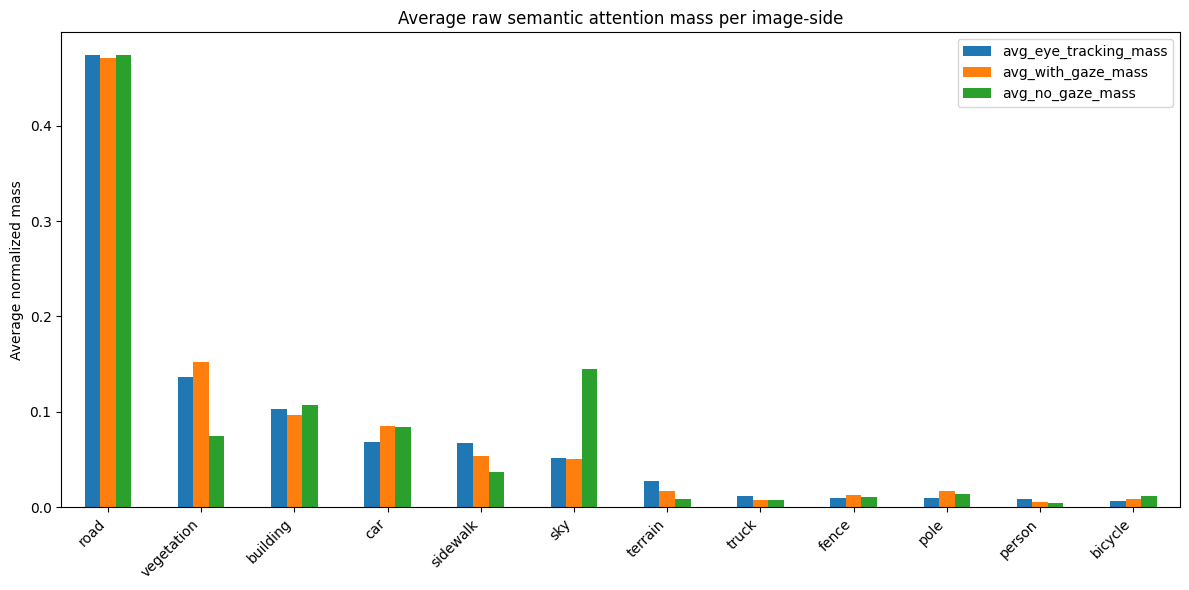

,avg_eye_tracking_mass,avg_with_gaze_mass,avg_no_gaze_mass
road,0.473930,0.470892,0.473766
vegetation,0.136579,0.152808,0.074531
building,0.102614,0.096530,0.107251
car,0.068854,0.085766,0.083860
sidewalk,0.067256,0.053677,0.037025
sky,0.051987,0.050717,0.145098
terrain,0.027825,0.016752,0.008954
truck,0.011472,0.007760,0.007952
fence,0.010015,0.012782,0.011057
pole,0.009770,0.016848,0.014069


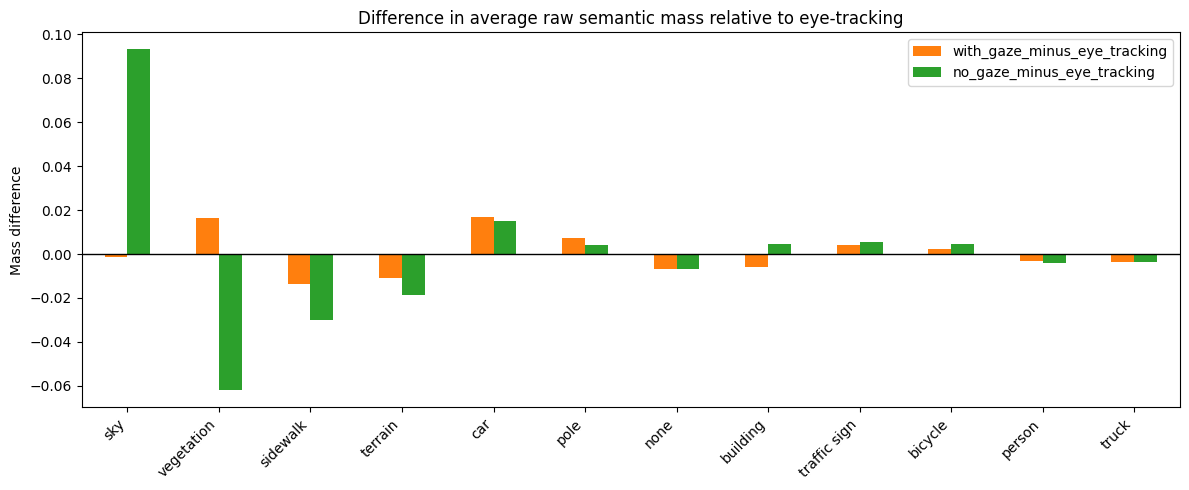

,with_gaze_minus_eye_tracking,no_gaze_minus_eye_tracking
sky,-0.001270,0.093111
vegetation,0.016229,-0.062048
sidewalk,-0.013579,-0.030230
terrain,-0.011073,-0.018871
car,0.016912,0.015006
pole,0.007077,0.004299
none,-0.006672,-0.006672
building,-0.006085,0.004637
traffic sign,0.004049,0.005274
bicycle,0.002310,0.004645


In [23]:
# Define a consistent color palette using default matplotlib hex codes
color_eye_tracking = '#1f77b4'  # Blue
color_with_gaze = '#ff7f0e'     # Orange
color_no_gaze = '#2ca02c'       # Green

plot_df_mass = (
    df_mean_semantic.loc[
        :,
        ["avg_eye_tracking_mass", "avg_with_gaze_mass", "avg_no_gaze_mass"]
    ]
    .sort_values("avg_eye_tracking_mass", ascending=False)
    .head(12)
)

# Apply colors to the first plot
ax = plot_df_mass.plot(
    kind="bar", 
    figsize=(12, 6),
    color=[color_eye_tracking, color_with_gaze, color_no_gaze]
)
ax.set_title("Average raw semantic attention mass per image-side")
ax.set_ylabel("Average normalized mass")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(plot_df_mass)

diff_vs_human = pd.DataFrame({
    "with_gaze_minus_eye_tracking": (
        df_mean_semantic["avg_with_gaze_mass"] - df_mean_semantic["avg_eye_tracking_mass"]
    ),
    "no_gaze_minus_eye_tracking": (
        df_mean_semantic["avg_no_gaze_mass"] - df_mean_semantic["avg_eye_tracking_mass"]
    ),
})

diff_vs_human["abs_with"] = diff_vs_human["with_gaze_minus_eye_tracking"].abs()
diff_vs_human["abs_no"] = diff_vs_human["no_gaze_minus_eye_tracking"].abs()
diff_vs_human["max_abs_diff"] = diff_vs_human[["abs_with", "abs_no"]].max(axis=1)

plot_diff_vs_human = (
    diff_vs_human
    .sort_values("max_abs_diff", ascending=False)
    .head(12)
    .loc[:, ["with_gaze_minus_eye_tracking", "no_gaze_minus_eye_tracking"]]
)

# Apply matching colors to the second plot
ax = plot_diff_vs_human.plot(
    kind="bar", 
    figsize=(12, 5),
    color=[color_with_gaze, color_no_gaze]
)
ax.set_title("Difference in average raw semantic mass relative to eye-tracking")
ax.set_ylabel("Mass difference")
ax.set_xlabel("")
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(
    diff_vs_human.loc[
        plot_diff_vs_human.index,
        ["with_gaze_minus_eye_tracking", "no_gaze_minus_eye_tracking"]
    ]
)

### 9.3) Average object size

Shows the average semantic object size per image-side after the same resize and center-crop geometry used by the model input.

This provides the baseline needed to interpret raw semantic attention mass.

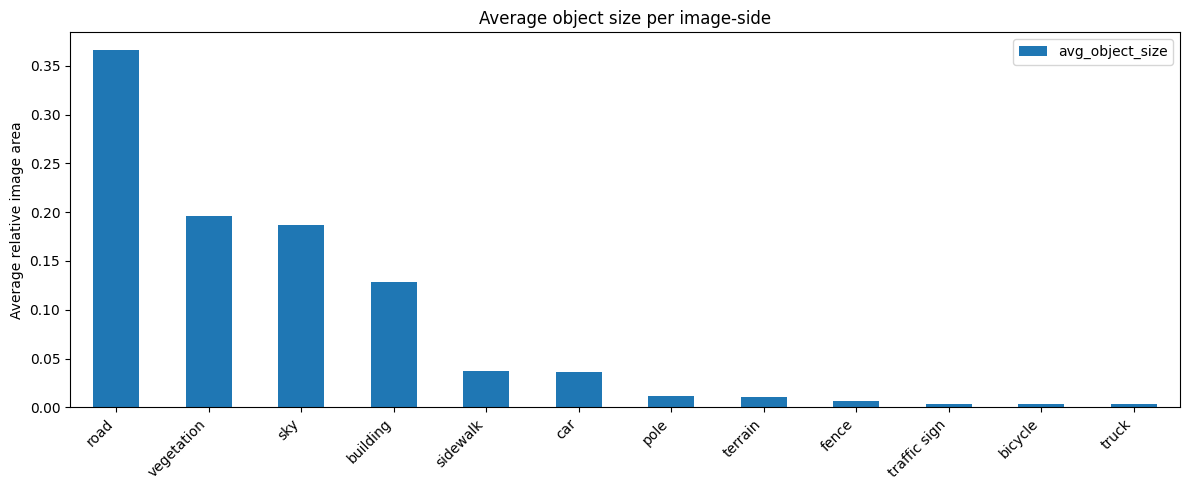

,avg_object_size
road,0.365888
vegetation,0.196280
sky,0.186868
building,0.127966
sidewalk,0.037747
car,0.036216
pole,0.011577
terrain,0.010795
fence,0.007077
traffic sign,0.003605


In [15]:
plot_df_size = (
    df_mean_semantic[["avg_object_size"]]
    .sort_values("avg_object_size", ascending=False)
    .head(12)
)

ax = plot_df_size.plot(kind="bar", figsize=(12, 5))
ax.set_title("Average object size per image-side")
ax.set_ylabel("Average relative image area")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(plot_df_size)

### 9.4) Global semantic enrichment

Computes semantic enrichment as:

\[
\text{global enrichment} = \frac{\text{average semantic mass}}{\text{average object size}}
\]

This shows which objects receive more attention than expected from their visual size.

Objects in summary: 19


,avg_object_size,avg_eye_tracking_mass,avg_with_gaze_mass,avg_no_gaze_mass,eye_tracking,with_gaze,without_gaze,with_minus_without
person,0.001887,0.008644,0.005411,0.004404,4.580241,2.867220,2.333723,0.533497
truck,0.003315,0.011723,0.007760,0.007952,3.536026,2.340623,2.398480,-0.057857
rider,0.002453,0.006474,0.007532,0.005892,2.638707,3.069892,2.401690,0.668202
terrain,0.010795,0.027941,0.016752,0.008954,2.588419,1.551830,0.829454,0.722377
wall,0.002027,0.004602,0.003033,0.002379,2.270378,1.496465,1.173608,0.322856
bicycle,0.003496,0.007145,0.009330,0.011664,2.043785,2.668760,3.336599,-0.667839
motorcycle,0.000456,0.000872,0.000731,0.000809,1.911174,1.603072,1.774651,-0.171579
car,0.036216,0.069014,0.085766,0.083860,1.905617,2.368179,2.315551,0.052628
sidewalk,0.037747,0.067771,0.053677,0.037025,1.795397,1.422010,0.980880,0.441130
fence,0.007077,0.010015,0.012782,0.011057,1.415095,1.805962,1.562316,0.243646


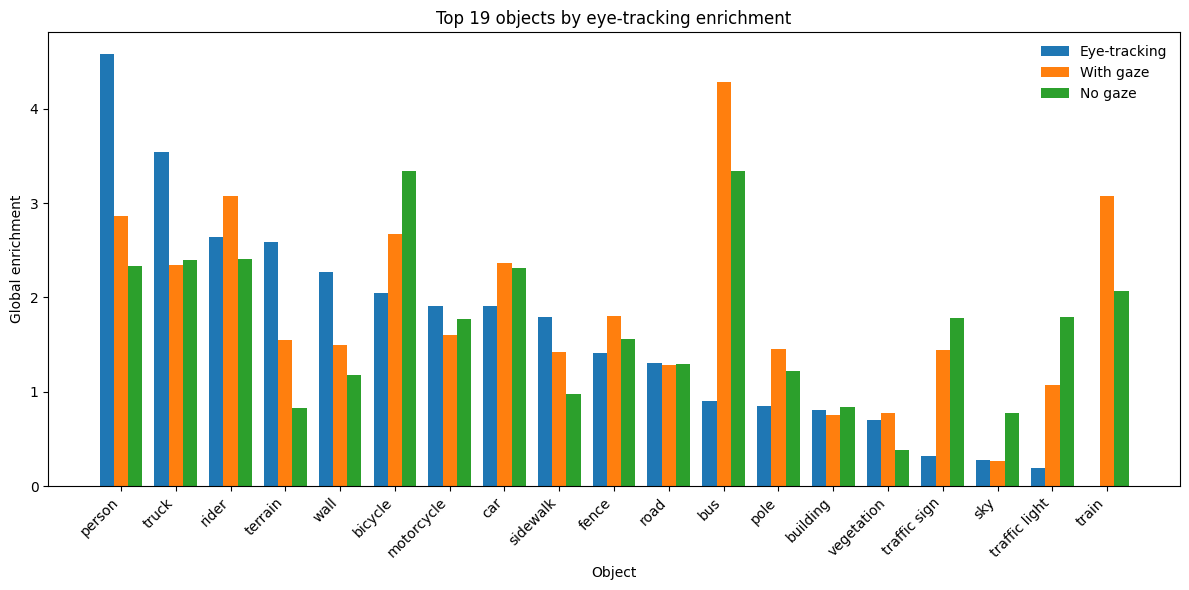

In [73]:
# --- 9.4) Global semantic enrichment ---
# Formula:
# global_enrichment(object) = average_semantic_mass(object) / average_object_size(object)

def global_enrichment_from_means(mean_mass: pd.Series, mean_area: pd.Series, eps: float = 1e-12) -> pd.Series:
    idx = sorted(set(mean_mass.index) | set(mean_area.index))
    out = {}

    for obj in idx:
        if obj in IGNORE_LABELS:
            continue

        avg_mass = float(mean_mass.get(obj, 0.0))
        avg_area = float(mean_area.get(obj, 0.0))

        if avg_area <= 0:
            continue

        out[obj] = avg_mass / max(avg_area, eps)

    return pd.Series(out, dtype=float)


# Mean distributions from cell 13 quantities
mean_area  = mean_dist_column(df_units, "area_dist")
mean_human = mean_dist_column(df_units, "human_dist")
mean_with  = mean_dist_column(df_units, "with_mass_dist")
mean_no    = mean_dist_column(df_units, "no_mass_dist")

# Global enrichment per source
global_enrich_human = global_enrichment_from_means(mean_human, mean_area)
global_enrich_with  = global_enrichment_from_means(mean_with, mean_area)
global_enrich_no    = global_enrichment_from_means(mean_no, mean_area)

# Summary table
df_global_enrichment = pd.concat(
    [
        mean_area.rename("avg_object_size"),
        mean_human.rename("avg_eye_tracking_mass"),
        mean_with.rename("avg_with_gaze_mass"),
        mean_no.rename("avg_no_gaze_mass"),
        global_enrich_human.rename("eye_tracking"),
        global_enrich_with.rename("with_gaze"),
        global_enrich_no.rename("without_gaze"),
    ],
    axis=1
).fillna(0.0)

df_global_enrichment["with_minus_without"] = (
    df_global_enrichment["with_gaze"] - df_global_enrichment["without_gaze"]
)

# Order bars by eye-tracking enrichment
df_plot = df_global_enrichment.sort_values("eye_tracking", ascending=False).copy()

print("Objects in summary:", len(df_plot))
display(df_plot)

# ------------------------------------------------------------
# Histogram / grouped bar chart ordered by eye-tracking
# ------------------------------------------------------------
top_k = 19
df_plot_top = df_plot.head(top_k).copy()

plt.figure(figsize=(12, 6))

x = np.arange(len(df_plot_top))
w = 0.26

plt.bar(x - w, df_plot_top["eye_tracking"].values, width=w, label="Eye-tracking")
plt.bar(x,     df_plot_top["with_gaze"].values,  width=w, label="With gaze")
plt.bar(x + w, df_plot_top["without_gaze"].values, width=w, label="No gaze")

plt.xticks(x, df_plot_top.index, rotation=45, ha="right")
plt.ylabel("Global enrichment")
plt.xlabel("Object")
plt.title(f"Top {top_k} objects by eye-tracking enrichment")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### 9.5) Intuitive top-object definitions

Counts the dominant semantic object per image-side using two intuitive definitions:

1. **Peak top object**  
   the object with the highest semantic mass in that image-side

2. **Area-corrected top object**  
   the object with the highest size-corrected semantic mass

These definitions are more interpretable than using total accumulated class mass across the whole image.

Objects in area-corrected summary: 19


,eye_tracking_area_corrected,with_gaze_area_corrected,without_gaze_area_corrected,with_minus_without
road,0.243693,0.062576,0.095550,-0.032974
car,0.151028,0.140416,0.156411,-0.015995
sidewalk,0.140995,0.083035,0.070344,0.012692
building,0.116369,0.044261,0.065636,-0.021376
vegetation,0.102417,0.044197,0.026423,0.017774
terrain,0.068423,0.074924,0.044468,0.030456
sky,0.038100,0.012662,0.047530,-0.034868
person,0.030363,0.075272,0.056744,0.018528
pole,0.029870,0.072843,0.071125,0.001718
fence,0.024351,0.061525,0.051928,0.009596


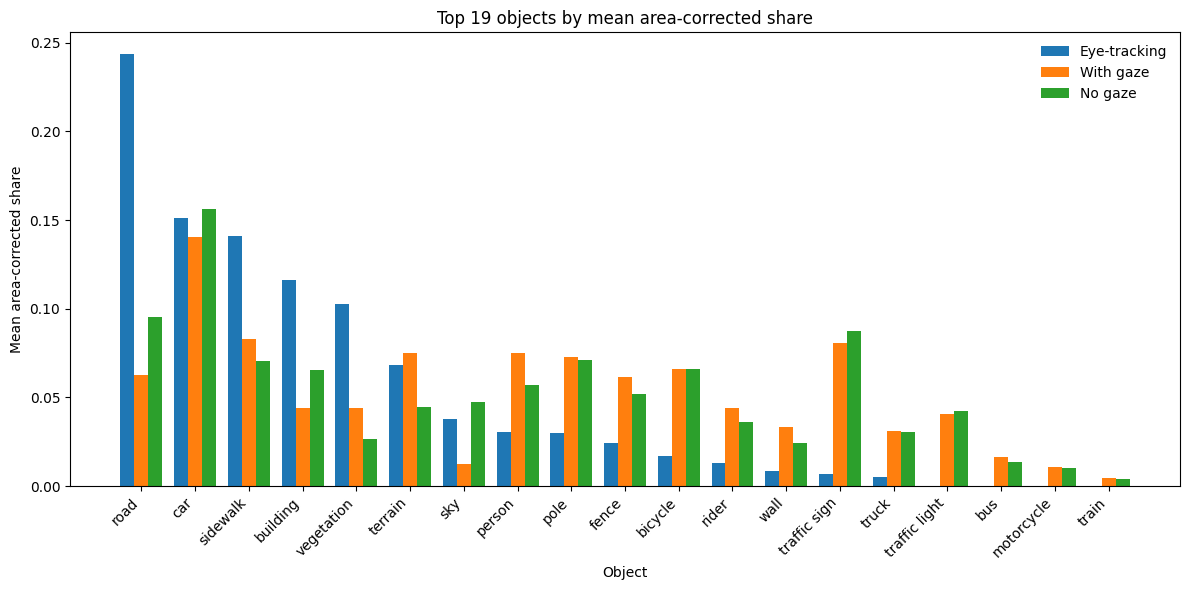

In [80]:
# --- 9.5) Mean area-corrected distributions (the 2nd quantity) ---
# This summarizes the per-unit outputs of:
# area_correct_distribution(attn_dist, area_dist, ...)
#
# Result meaning:
# For each object, value = average share of the within-image area-corrected enrichment
# after per-image renormalization.

mean_human_area_corrected = mean_dist_column(df_units, "human_area_corrected_dist")
mean_with_area_corrected  = mean_dist_column(df_units, "with_area_corrected_dist")
mean_no_area_corrected    = mean_dist_column(df_units, "no_area_corrected_dist")

df_area_corrected_summary = pd.concat(
    [
        mean_human_area_corrected.rename("eye_tracking_area_corrected"),
        mean_with_area_corrected.rename("with_gaze_area_corrected"),
        mean_no_area_corrected.rename("without_gaze_area_corrected"),
    ],
    axis=1
).fillna(0.0)

df_area_corrected_summary["with_minus_without"] = (
    df_area_corrected_summary["with_gaze_area_corrected"]
    - df_area_corrected_summary["without_gaze_area_corrected"]
)

# Order by human area-corrected value
df_plot_area_corrected = df_area_corrected_summary.sort_values(
    "eye_tracking_area_corrected",
    ascending=False
).copy()

print("Objects in area-corrected summary:", len(df_plot_area_corrected))
display(df_plot_area_corrected)

# ------------------------------------------------------------
# Grouped bar chart for the 2nd quantity
# ------------------------------------------------------------
top_k = 19
df_plot_top = df_plot_area_corrected.head(top_k).copy()

plt.figure(figsize=(12, 6))

x = np.arange(len(df_plot_top))
w = 0.26

plt.bar(x - w, df_plot_top["eye_tracking_area_corrected"].values, width=w, label="Eye-tracking")
plt.bar(x,     df_plot_top["with_gaze_area_corrected"].values,  width=w, label="With gaze")
plt.bar(x + w, df_plot_top["without_gaze_area_corrected"].values, width=w, label="No gaze")

plt.xticks(x, df_plot_top.index, rotation=45, ha="right")
plt.ylabel("Mean area-corrected share")
plt.xlabel("Object")
plt.title(f"Top {top_k} objects by mean area-corrected share")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [81]:
# --- Debug bus mismatches: area vs human attention ---
# Finds rows in df_units where:
# 1) bus area exists but human bus attention is zero
# 2) human bus attention exists but bus area is zero
#
# Output includes survey_id and trial_id.

TARGET_OBJ = "bus"
EPS = 1e-12

def get_obj_value(d, key, default=0.0):
    if not isinstance(d, dict):
        return default
    try:
        return float(d.get(key, default))
    except Exception:
        return default

df_bus_debug = df_units.copy()

df_bus_debug["bus_area"] = df_bus_debug["area_dist"].apply(lambda d: get_obj_value(d, TARGET_OBJ, 0.0))
df_bus_debug["bus_human"] = df_bus_debug["human_dist"].apply(lambda d: get_obj_value(d, TARGET_OBJ, 0.0))
df_bus_debug["bus_with"] = df_bus_debug["with_mass_dist"].apply(lambda d: get_obj_value(d, TARGET_OBJ, 0.0))
df_bus_debug["bus_no"] = df_bus_debug["no_mass_dist"].apply(lambda d: get_obj_value(d, TARGET_OBJ, 0.0))

# Case A: bus area exists, but humans gave no bus attention
df_bus_area_no_human = df_bus_debug[
    (df_bus_debug["bus_area"] > EPS) & (df_bus_debug["bus_human"] <= EPS)
].copy()

# Case B: humans gave bus attention, but bus area is missing/zero
df_bus_human_no_area = df_bus_debug[
    (df_bus_debug["bus_human"] > EPS) & (df_bus_debug["bus_area"] <= EPS)
].copy()

cols_show = [
    "bundle",
    "survey_id",
    "trial_id",
    "side",
    "bus_area",
    "bus_human",
    "bus_with",
    "bus_no",
]

print("Case A: bus area > 0 but human bus attention == 0")
print("Rows:", len(df_bus_area_no_human))
display(
    df_bus_area_no_human[cols_show]
    .sort_values(["bus_area", "survey_id", "trial_id"], ascending=[False, True, True])
    .reset_index(drop=True)
)

print("\nCase B: human bus attention > 0 but bus area == 0")
print("Rows:", len(df_bus_human_no_area))
display(
    df_bus_human_no_area[cols_show]
    .sort_values(["bus_human", "survey_id", "trial_id"], ascending=[False, True, True])
    .reset_index(drop=True)
)

# Optional compact unique trial summaries
print("\nUnique (survey_id, trial_id) for Case A:")
display(
    df_bus_area_no_human[["survey_id", "trial_id"]]
    .drop_duplicates()
    .sort_values(["survey_id", "trial_id"])
    .reset_index(drop=True)
)

print("\nUnique (survey_id, trial_id) for Case B:")
display(
    df_bus_human_no_area[["survey_id", "trial_id"]]
    .drop_duplicates()
    .sort_values(["survey_id", "trial_id"])
    .reset_index(drop=True)
)

Case A: bus area > 0 but human bus attention == 0
Rows: 27


,bundle,survey_id,trial_id,side,bus_area,bus_human,bus_with,bus_no
0,ViT,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,57,l,0.022361,0.0,0.031502,0.020991
1,ViT,cyclingdbdde36bbe3344b160d31a87c5d85169c366502...,27,l,0.017977,0.0,0.087627,0.098246
2,ViT,cycling5e970a9dfb4a47cae2526d10a49e351fa97d26d...,6,r,0.012197,0.0,0.037463,0.029966
3,ViT,cycling4c845f8ebd5f514f1fdc690d2ab60d5f8beb818...,41,r,0.010483,0.0,0.066549,0.068359
4,ViT,cycling5876966995d4b61ed7073ec1ea1a92e1d3bcfbb...,33,r,0.010423,0.0,0.057177,0.030388
5,ViT,cycling4c845f8ebd5f514f1fdc690d2ab60d5f8beb818...,31,l,0.009825,0.0,0.071306,0.023733
6,ViT,cycling469572b0c7fe5cc0c5f020ebae513ffeae62ec4...,33,l,0.005620,0.0,0.024773,0.027592
7,ViT,cycling932844b29e6175a85d195cbee96ce34057d0b2c...,14,l,0.005142,0.0,0.021469,0.023605
8,ViT,cycling132c5e4c5b0a45e274e7fb849fecd22e62edf40...,24,l,0.002053,0.0,0.004274,0.003412
9,ViT,cyclingd22a19aa45e85ca027d29be0fe3b839383d8566...,55,r,0.001614,0.0,0.015429,0.004376



Case B: human bus attention > 0 but bus area == 0
Rows: 1


,bundle,survey_id,trial_id,side,bus_area,bus_human,bus_with,bus_no
0,ViT,cycling4c845f8ebd5f514f1fdc690d2ab60d5f8beb818...,9,r,0.0,0.095346,0.0,0.0



Unique (survey_id, trial_id) for Case A:


,survey_id,trial_id
0,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,30
1,cycling08ab6849b6ce9851d50c230e82c8b2ba0564ffc...,57
2,cycling0a3df224a10f3472c2a9c568a927406a49b0121...,20
3,cycling0a3df224a10f3472c2a9c568a927406a49b0121...,42
4,cycling132c5e4c5b0a45e274e7fb849fecd22e62edf40...,24
5,cycling132c5e4c5b0a45e274e7fb849fecd22e62edf40...,60
6,cycling28b744c8c0b8b330c7f678d5b23aa2ce614a5ae...,27
7,cycling469572b0c7fe5cc0c5f020ebae513ffeae62ec4...,33
8,cycling4c845f8ebd5f514f1fdc690d2ab60d5f8beb818...,16
9,cycling4c845f8ebd5f514f1fdc690d2ab60d5f8beb818...,31



Unique (survey_id, trial_id) for Case B:


,survey_id,trial_id
0,cycling4c845f8ebd5f514f1fdc690d2ab60d5f8beb818...,9


### 9.6) Agreement with eye-tracking

Reports how often each model matches the eye-tracking dominant semantic object using the intuitive top-object definitions.

In [18]:
display(agreement_summary.to_frame("agreement_rate"))

,agreement_rate
peak_top_agreement_with_human,0.543165
peak_top_agreement_no_human,0.460432
area_top_agreement_with_human,0.104317
area_top_agreement_no_human,0.100719


### 9.7) Human fixation intensity relative to object area

Relates fixation duration to semantic object area.

This helps connect raw fixation time to the normalization used in semantic attention mass.

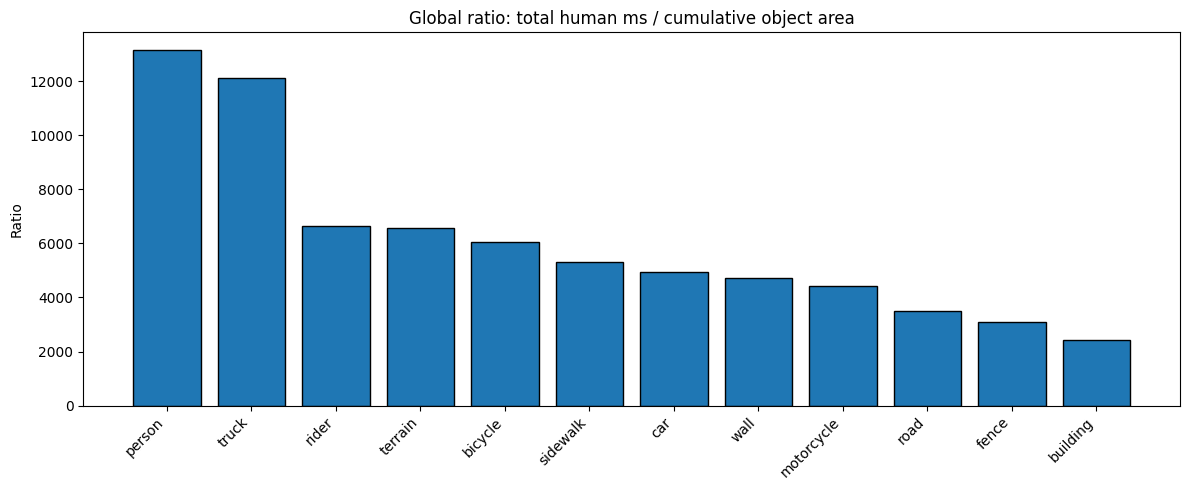

--- GLOBAL RATIO TABLE ---


,object,total_ms,total_area,global_ratio,total_area_px2_equiv,global_ratio_ms_px2
0,person,6594.0,0.501555,13147.124851,2.201383e+05,0.029954
1,truck,11156.0,0.921636,12104.563965,4.045170e+05,0.027579
2,rider,4516.0,0.678292,6657.895516,2.977107e+05,0.015169
3,terrain,19762.0,3.000937,6585.277184,1.317147e+06,0.015004
4,bicycle,5695.0,0.941307,6050.100993,4.131508e+05,0.013784
5,sidewalk,55035.0,10.395867,5293.930981,4.562871e+06,0.012061
6,car,49731.0,10.067742,4939.638126,4.418853e+06,0.011254
7,wall,2669.0,0.563536,4736.162965,2.473429e+05,0.010791
8,motorcycle,534.0,0.120316,4438.294517,5.280835e+04,0.010112
9,road,353824.0,101.388532,3489.783230,4.450064e+07,0.007951


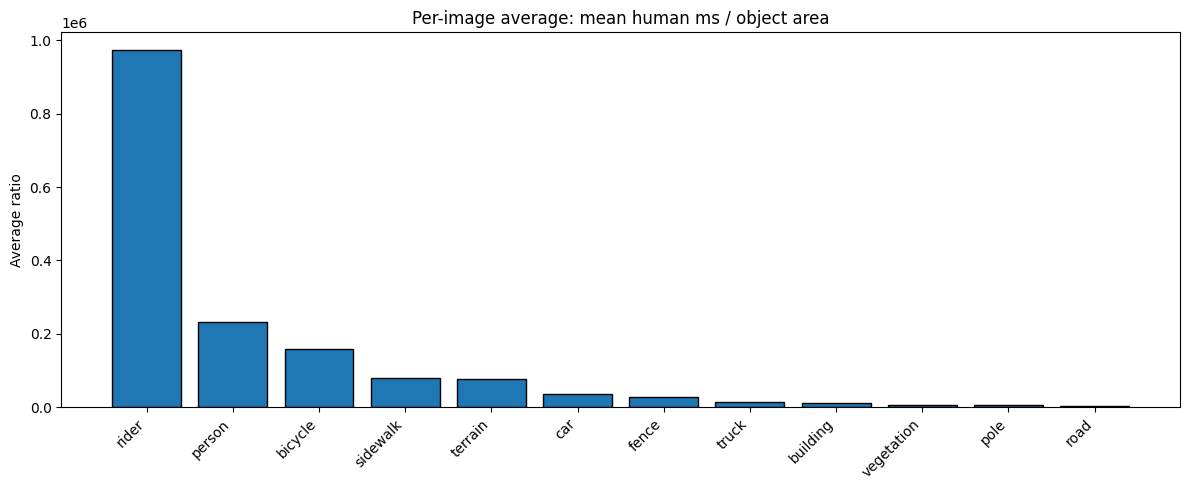


--- PER-IMAGE AVERAGE TABLE ---


,object,avg_intensity_ms_per_area_share,avg_intensity_ms_px2,eval_appearance_count
0,rider,972478.251808,2.215657,94
1,person,231451.506888,0.527330,172
2,bicycle,157999.323532,0.359980,144
3,sidewalk,81290.794461,0.185210,268
4,terrain,77358.159665,0.176250,221
5,car,35690.259286,0.081315,269
6,fence,28695.781361,0.065379,192
7,truck,14437.988083,0.032895,69
8,building,13308.031022,0.030320,273
9,vegetation,6886.930530,0.015691,275


In [79]:
# ============================================================================
# REPLACEMENT CELL
# Consistent with Cells 12 and 13
# ============================================================================

TOTAL_PIXELS = 864 * 508
EPS = 1e-12

# ----------------------------------------------------------------------------
# 0) Helpers
# ----------------------------------------------------------------------------
def _norm_key(x):
    return str(x).strip().lower()

def _clean_dist_local(d, ignore=None):
    ignore = set() if ignore is None else {_norm_key(x) for x in ignore}
    out = {}

    if not isinstance(d, dict):
        return out

    for k, v in d.items():
        kk = _norm_key(k)
        if kk in ignore:
            continue
        vv = float(v)
        if vv > 0:
            out[kk] = vv
    return out


def explode_weighted_mass(df, dist_col, unit_total_ms_col, out_col, ignore=None):
    rows = []

    for _, r in df.iterrows():
        d = _clean_dist_local(r[dist_col], ignore=ignore)
        unit_total_ms = float(r[unit_total_ms_col])

        for obj, p in d.items():
            rows.append({
                "object": obj,
                out_col: unit_total_ms * float(p),
            })

    if not rows:
        return pd.DataFrame(columns=["object", out_col])

    return (
        pd.DataFrame(rows)
        .groupby("object", as_index=False)[out_col]
        .sum()
    )


def explode_total_area(df, area_col, out_col, ignore=None):
    rows = []

    for _, r in df.iterrows():
        d = _clean_dist_local(r[area_col], ignore=ignore)

        for obj, a in d.items():
            rows.append({
                "object": obj,
                out_col: float(a),
            })

    if not rows:
        return pd.DataFrame(columns=["object", out_col])

    return (
        pd.DataFrame(rows)
        .groupby("object", as_index=False)[out_col]
        .sum()
    )


def explode_unit_intensity(df, mass_col, area_col, unit_total_ms_col, ignore=None):
    rows = []

    for _, r in df.iterrows():
        mass_d = _clean_dist_local(r[mass_col], ignore=ignore)
        area_d = _clean_dist_local(r[area_col], ignore=ignore)
        unit_total_ms = float(r[unit_total_ms_col])

        keys = sorted(set(mass_d.keys()) | set(area_d.keys()))
        for obj in keys:
            area_share = float(area_d.get(obj, 0.0))
            if area_share <= 0:
                continue

            obj_ms = unit_total_ms * float(mass_d.get(obj, 0.0))
            rows.append({
                "object": obj,
                "intensity_ms_per_area_share": obj_ms / max(area_share, EPS),
                "intensity_ms_px2": obj_ms / max(area_share * TOTAL_PIXELS, EPS),
            })

    if not rows:
        return pd.DataFrame(columns=[
            "object",
            "avg_intensity_ms_per_area_share",
            "avg_intensity_ms_px2",
            "eval_appearance_count",
        ])

    tmp = pd.DataFrame(rows)

    return (
        tmp.groupby("object", as_index=False)
           .agg(
               avg_intensity_ms_per_area_share=("intensity_ms_per_area_share", "mean"),
               avg_intensity_ms_px2=("intensity_ms_px2", "mean"),
               eval_appearance_count=("intensity_ms_per_area_share", "size"),
           )
    )


IGNORE_LABELS_INTENSITY = {"unmapped", "unknown", "nowhere", "", "none", None}

# ----------------------------------------------------------------------------
# 1) Strict semantic units, deduplicated at human/image level
#    Bundle is excluded on purpose so the same human/image unit is not counted
#    multiple times if df_units contains several bundles.
# ----------------------------------------------------------------------------
df_sem_units = (
    df_units
    .copy()
    .drop_duplicates(subset=["survey_id", "trial_id", "side"])
    .loc[:, ["survey_id", "trial_id", "side", "human_dist", "area_dist"]]
    .copy()
)

df_sem_units["survey_id"] = df_sem_units["survey_id"].astype(str).str.strip()
df_sem_units["trial_id"] = df_sem_units["trial_id"].astype(int)
df_sem_units["side"] = df_sem_units["side"].astype(str).str.strip()

# ----------------------------------------------------------------------------
# 2) Total human ms available in each semantic unit
#    Uses the raw OGAMA long table only to get the unit total viewing time,
#    then allocates that time with df_units["human_dist"] to stay aligned with
#    Cell 13 semantics.
# ----------------------------------------------------------------------------
unit_total_ms = (
    human_dist.copy()
    .assign(
        survey_id=lambda d: d["survey_id"].astype(str).str.strip(),
        trial_id=lambda d: d["trial_id"].astype(int),
        side=lambda d: d["side"].astype(str).str.strip(),
        w=lambda d: d["w"].astype(float),
    )
    .groupby(["survey_id", "trial_id", "side"], as_index=False)
    .agg(unit_total_ms=("w", "sum"))
)

df_sem_units = df_sem_units.merge(
    unit_total_ms,
    on=["survey_id", "trial_id", "side"],
    how="inner"
).copy()

# ----------------------------------------------------------------------------
# 3) GLOBAL RATIO: total ms / cumulative area share
# ----------------------------------------------------------------------------
tbl_total_ms = explode_weighted_mass(
    df=df_sem_units,
    dist_col="human_dist",
    unit_total_ms_col="unit_total_ms",
    out_col="total_ms",
    ignore=IGNORE_LABELS_INTENSITY,
)

tbl_total_area = explode_total_area(
    df=df_sem_units,
    area_col="area_dist",
    out_col="total_area",
    ignore=IGNORE_LABELS_INTENSITY,
)

df_global = (
    tbl_total_ms
    .merge(tbl_total_area, on="object", how="outer")
    .fillna(0.0)
)

df_global = df_global[df_global["total_area"] > 0].copy()
df_global["global_ratio"] = df_global["total_ms"] / df_global["total_area"].clip(lower=EPS)
df_global["total_area_px2_equiv"] = df_global["total_area"] * TOTAL_PIXELS
df_global["global_ratio_ms_px2"] = df_global["total_ms"] / df_global["total_area_px2_equiv"].clip(lower=EPS)

df_global = df_global.sort_values("global_ratio", ascending=False).reset_index(drop=True)

# Histogram: Global ratio
plot_global = df_global.head(12).copy()

plt.figure(figsize=(12, 5))
plt.bar(plot_global["object"], plot_global["global_ratio"], edgecolor="black")
plt.title("Global ratio: total human ms / cumulative object area")
plt.ylabel("Ratio")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("--- GLOBAL RATIO TABLE ---")
display(df_global)

# ----------------------------------------------------------------------------
# 4) PER-IMAGE AVERAGE: mean over semantic units of (object ms / area share)
# ----------------------------------------------------------------------------
df_per_image = explode_unit_intensity(
    df=df_sem_units,
    mass_col="human_dist",
    area_col="area_dist",
    unit_total_ms_col="unit_total_ms",
    ignore=IGNORE_LABELS_INTENSITY,
)

df_per_image = df_per_image.sort_values(
    "avg_intensity_ms_per_area_share",
    ascending=False
).reset_index(drop=True)

# Histogram: Per-image average ratio
plot_per_image = df_per_image.head(12).copy()

plt.figure(figsize=(12, 5))
plt.bar(plot_per_image["object"], plot_per_image["avg_intensity_ms_per_area_share"], edgecolor="black")
plt.title("Per-image average: mean human ms / object area")
plt.ylabel("Average ratio")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n--- PER-IMAGE AVERAGE TABLE ---")
display(df_per_image)

### 9.8) Qualitative candidate cases

Selects image-sides where the gaze-trained model matches the eye-tracking dominant object after area correction, while the model trained without gaze does not.

These cases are useful for qualitative figures.

In [20]:
display(
    interesting_cases.loc[
        :,
        [
            "bundle", "survey_id", "trial_id", "side",
            "human_top", "with_mass_top", "no_mass_top",
            "human_peak_top", "with_peak_top", "no_peak_top",
            "human_area_top", "with_area_top", "no_area_top",
            "human_dist", "with_mass_dist", "no_mass_dist", "area_dist"
        ]
    ].head(20)
)

print("Interesting cases:", len(interesting_cases))

,bundle,survey_id,trial_id,side,human_top,with_mass_top,no_mass_top,human_peak_top,with_peak_top,no_peak_top,human_area_top,with_area_top,no_area_top,human_dist,with_mass_dist,no_mass_dist,area_dist
15,ViT,cycling4c845f8ebd5f514f1fdc690d2ab60d5f8beb818...,62,r,road,road,road,road,road,road,car,car,pole,"{'building': 0.08530034185251507, 'car': 0.180...","{'sky': 0.01986729245762419, 'vegetation': 0.4...","{'sky': 0.16042009995769174, 'vegetation': 0.2...","{'sky': 0.21231265943877556, 'vegetation': 0.3..."
18,ViT,cyclingdbdde36bbe3344b160d31a87c5d85169c366502...,55,l,rider,road,road,rider,road,road,rider,rider,bicycle,"{'car': 0.043478260869565216, 'rider': 0.73084...","{'building': 0.13032230973056239, 'sky': 0.039...","{'building': 0.14441858754564219, 'sky': 0.014...","{'building': 0.2274394132653061, 'sky': 0.1354..."
21,ViT,cycling684fdee4e2ba556e4e23a3f68062835cf9796ce...,15,r,road,road,road,road,road,road,sidewalk,sidewalk,bicycle,"{'building': 0.19098143236074272, 'car': 0.102...","{'building': 0.03691294308841923, 'sky': 0.131...","{'building': 0.019690127278038073, 'sky': 0.08...","{'building': 0.08741230867346933, 'sky': 0.269..."
51,ViT,cyclingbd1af6d2f4bda83c3d5d6dfc93817421d804a64...,6,r,road,road,road,road,road,road,car,car,pole,"{'building': 0.05909694555112882, 'car': 0.066...","{'sky': 0.02633749832036832, 'vegetation': 0.2...","{'sky': 0.17393127159989555, 'vegetation': 0.1...","{'sky': 0.22247688137755098, 'vegetation': 0.3..."
59,ViT,cyclingdbdde36bbe3344b160d31a87c5d85169c366502...,6,r,road,road,road,road,road,road,sidewalk,sidewalk,car,"{'building': 0.37569296375266525, 'none': 0.02...","{'building': 0.23386072446060469, 'sky': 0.010...","{'building': 0.33727304514369516, 'sky': 0.004...","{'building': 0.42010124362244905, 'sky': 0.033..."
64,ViT,cycling469572b0c7fe5cc0c5f020ebae513ffeae62ec4...,33,l,road,road,road,road,road,road,car,car,bus,"{'building': 0.01721439749608764, 'car': 0.478...","{'sky': 0.10702154542929189, 'vegetation': 0.1...","{'sky': 0.2864079291550058, 'vegetation': 0.04...","{'sky': 0.3679846938775511, 'vegetation': 0.13..."
90,ViT,cycling5e970a9dfb4a47cae2526d10a49e351fa97d26d...,2,l,road,road,sky,road,road,sky,road,road,traffic light,"{'pole': 0.09264909847434119, 'road': 0.681276...","{'pole': 0.016437536399333284, 'traffic sign':...","{'pole': 0.011817701475158291, 'traffic sign':...","{'pole': 0.01181839923469388, 'traffic sign': ..."
94,ViT,cycling469572b0c7fe5cc0c5f020ebae513ffeae62ec4...,35,l,road,road,road,road,road,road,car,car,traffic sign,"{'car': 0.12931538911644236, 'road': 0.8706846...","{'sky': 0.04709176600266865, 'vegetation': 0.3...","{'sky': 0.20085247625922342, 'vegetation': 0.1...","{'sky': 0.19160554846938763, 'vegetation': 0.3..."
98,ViT,cycling28b744c8c0b8b330c7f678d5b23aa2ce614a5ae...,15,l,vegetation,road,road,vegetation,road,road,pole,pole,road,"{'none': 0.08703923900118907, 'pole': 0.062306...","{'building': 0.13690125141376014, 'vegetation'...","{'building': 0.07755639136803645, 'vegetation'...","{'building': 0.20125159438775497, 'vegetation'..."
99,ViT,cycling28b744c8c0b8b330c7f678d5b23aa2ce614a5ae...,15,r,vegetation,road,road,vegetation,road,road,car,car,traffic sign,"{'car': 0.20022497187851518, 'road': 0.1754780...","{'building': 0.185786262004752, 'pole': 0.0155...","{'building': 0.14950794653777164, 'pole': 0.01...","{'building': 0.17883051658163268, 'pole': 0.01..."


Interesting cases: 20


### 9.9) Phase 1: Top-1 Semantic Agreement

This measures how often the model's absolute primary focus matches the human's primary focus.

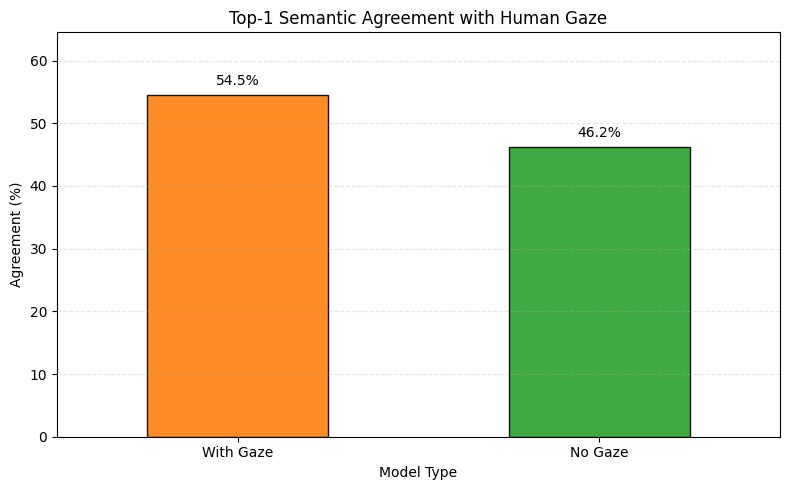

,Top-1 Accuracy (%)
model,
no_gaze,46.209386
with_gaze,54.512635


In [42]:
# Drop cases where either human or model didn't have a valid top label
df_valid_top = df_results.dropna(subset=["human_top", "model_top"]).copy()

# Calculate agreement
df_valid_top["top1_match"] = (df_valid_top["human_top"] == df_valid_top["model_top"])

top1_acc = df_valid_top.groupby("model")["top1_match"].mean() * 100

# Plotting
plt.figure(figsize=(8, 5))
ax = top1_acc.loc[["with_gaze", "no_gaze"]].plot(
    kind="bar", 
    color=['#ff7f0e', '#2ca02c'], 
    edgecolor='black',
    alpha=0.9
)

ax.set_title("Top-1 Semantic Agreement with Human Gaze")
ax.set_ylabel("Agreement (%)")
ax.set_xlabel("Model Type")
ax.set_xticklabels(["With Gaze", "No Gaze"], rotation=0)

# Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.ylim(0, max(top1_acc) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

display(top1_acc.to_frame("Top-1 Accuracy (%)"))

### 9.10) Phase 1: Confusion Matrix of Attention

This visualizes exactly *where* the models get confused when their primary focus disagrees with the human's focus.

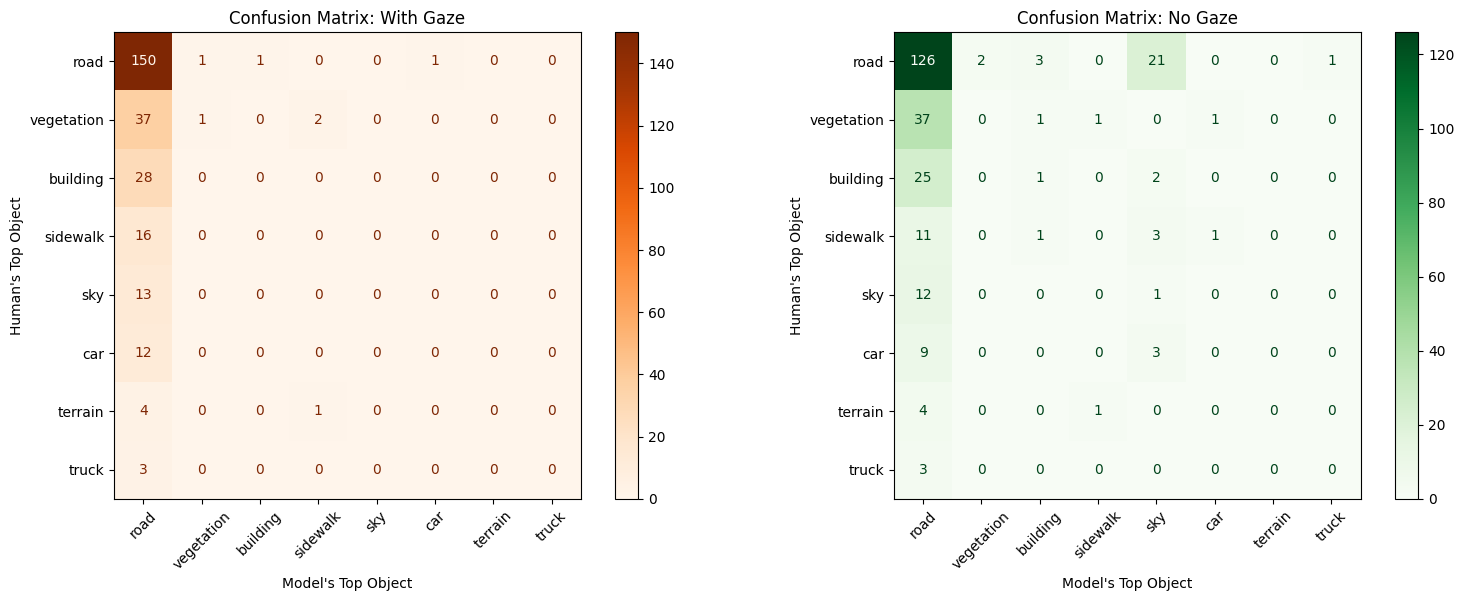

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the top 8 most common human focus objects to keep the matrix readable
top_classes = df_valid_top["human_top"].value_counts().head(8).index.tolist()

# Filter to only rows where both human and model predicted one of the top classes
df_cm = df_valid_top[
    df_valid_top["human_top"].isin(top_classes) & 
    df_valid_top["model_top"].isin(top_classes)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, model_name in enumerate(["with_gaze", "no_gaze"]):
    sub = df_cm[df_cm["model"] == model_name]
    
    cm = confusion_matrix(sub["human_top"], sub["model_top"], labels=top_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_classes)
    
    # Use distinct colormaps for visual clarity
    cmap = "Oranges" if model_name == "with_gaze" else "Greens"
    disp.plot(ax=axes[i], cmap=cmap, xticks_rotation=45)
    
    axes[i].set_title(f"Confusion Matrix: {model_name.replace('_', ' ').title()}")
    axes[i].set_xlabel("Model's Top Object")
    axes[i].set_ylabel("Human's Top Object")

plt.tight_layout()
plt.show()

### 9.11) Phase 2: Jensen-Shannon Divergence (JSD)

JSD measures how close the *entire probability distributions* are to each other. A lower score means the model's overall allocation of attention is mathematically closer to human behavior.

/tmp/ipykernel_1819459/1154693732.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data, patch_artist=True, labels=labels,


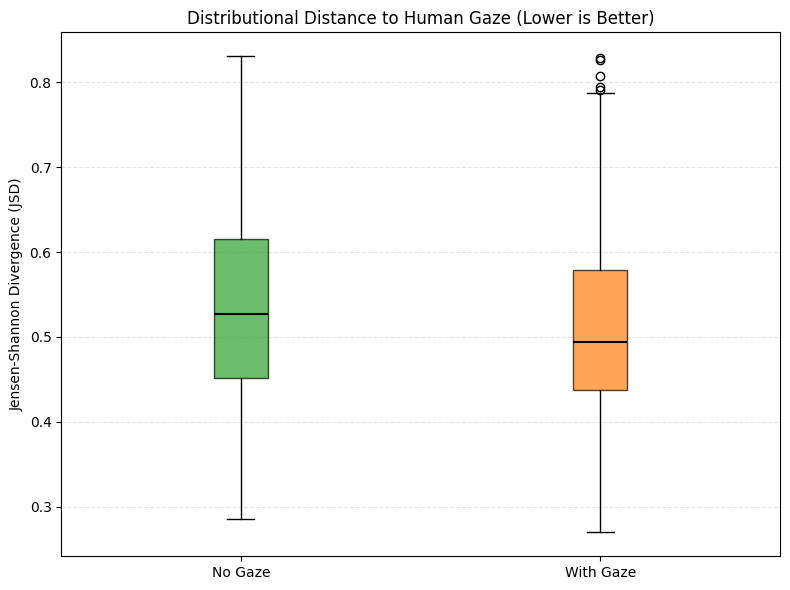

,Mean JSD (Lower is better)
model,
no_gaze,0.533722
with_gaze,0.513001


In [44]:
# ----------------------------------------------------------------------------
# 9.11) Jensen-Shannon Divergence (Overall Distributional Similarity)
# ----------------------------------------------------------------------------
from scipy.spatial.distance import jensenshannon

jsd_records = []

for _, r in df_results.iterrows():
    h_dist = r.get("human_dist", {})
    m_dist = r.get("model_dist", {})
    
    if not h_dist or not m_dist:
        continue
        
    # Align the dictionaries into flat arrays for comparison
    p, q, _ = align_distributions(h_dist, m_dist)
    
    # Calculate JSD (0.0 = identical distributions, 1.0 = completely different)
    val = jensenshannon(p, q)
    if np.isfinite(val):
        jsd_records.append({
            "model": r["model"],
            "jsd": float(val)
        })

df_jsd = pd.DataFrame(jsd_records)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Map colors to match previous plots
color_dict = {"with_gaze": "#ff7f0e", "no_gaze": "#2ca02c"}

# Group the data
grouped = df_jsd.groupby("model")["jsd"].apply(list)
labels = ["No Gaze", "With Gaze"] # Ordered for display
data = [grouped["no_gaze"], grouped["with_gaze"]]
colors = [color_dict["no_gaze"], color_dict["with_gaze"]]

bplot = ax.boxplot(data, patch_artist=True, labels=labels, 
                   medianprops=dict(color='black', linewidth=1.5))

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Distributional Distance to Human Gaze (Lower is Better)")
ax.set_ylabel("Jensen-Shannon Divergence (JSD)")
ax.set_xlabel("")
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Display mean JSD
display(df_jsd.groupby("model")["jsd"].mean().to_frame("Mean JSD (Lower is better)"))

### 9.12) Actor-Level Attention Scaling

Do the models correctly scale their attention based on critical actors like pedestrians and cars? This scatter plot compares human attention mass vs. model attention mass on a per-image basis.

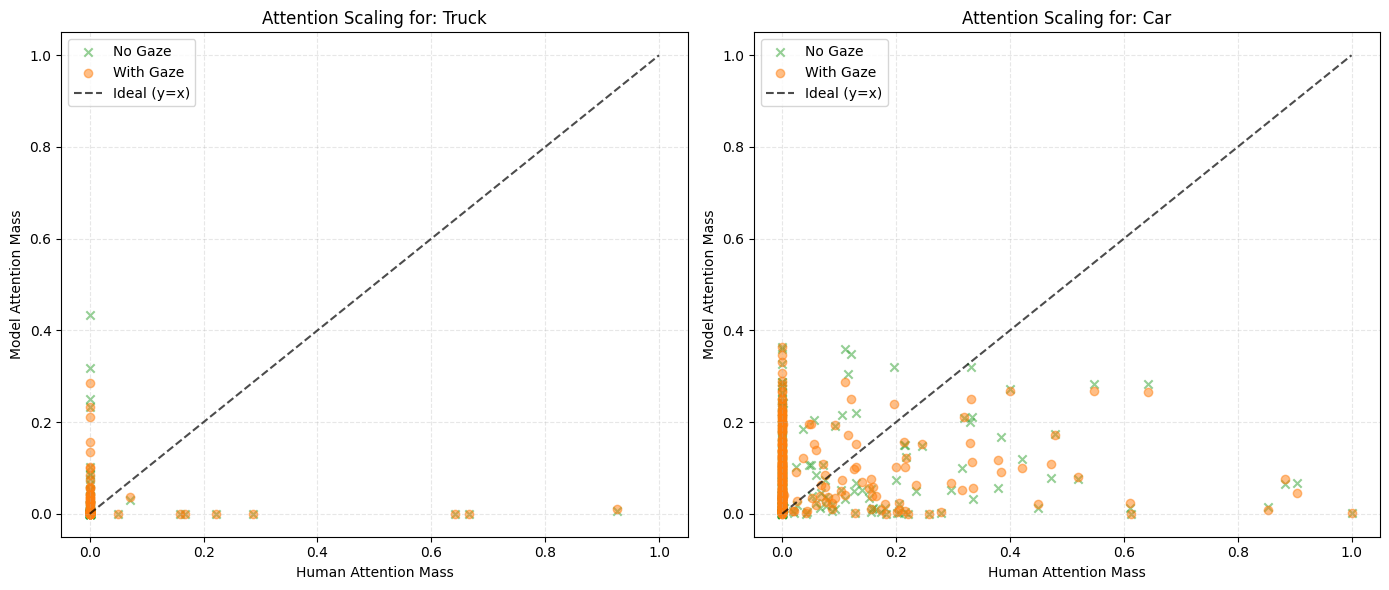

In [50]:
# ----------------------------------------------------------------------------
# 9.12) Actor-Level Attention Scaling (Person & Car)
# ----------------------------------------------------------------------------
target_classes = ["truck", "car"]
scatter_data = []

for _, r in df_results.iterrows():
    h_dist = r.get("human_dist", {})
    m_dist = r.get("model_dist", {})
    
    for cls in target_classes:
        h_mass = h_dist.get(cls, 0.0)
        m_mass = m_dist.get(cls, 0.0)
        
        # Only plot if the human actually looked at it or the model predicted it
        if h_mass > 0 or m_mass > 0:
            scatter_data.append({
                "model": r["model"],
                "class": cls,
                "human_mass": h_mass,
                "model_mass": m_mass
            })

df_scatter = pd.DataFrame(scatter_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, cls in enumerate(target_classes):
    sub = df_scatter[df_scatter["class"] == cls]
    
    with_gaze = sub[sub["model"] == "with_gaze"]
    no_gaze = sub[sub["model"] == "no_gaze"]
    
    # Plot No Gaze (Green crosses)
    axes[i].scatter(no_gaze["human_mass"], no_gaze["model_mass"], 
                    alpha=0.5, color='#2ca02c', label="No Gaze", marker='x')
    
    # Plot With Gaze (Orange dots)
    axes[i].scatter(with_gaze["human_mass"], with_gaze["model_mass"], 
                    alpha=0.5, color='#ff7f0e', label="With Gaze", marker='o')
    
    # Ideal diagonal line (y = x)
    axes[i].plot([0, 1], [0, 1], 'k--', label="Ideal (y=x)", alpha=0.7)
    
    axes[i].set_title(f"Attention Scaling for: {cls.capitalize()}")
    axes[i].set_xlabel("Human Attention Mass")
    axes[i].set_ylabel("Model Attention Mass")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 9.13) Phase 4: The Correction Shift

This final chart explicitly shows what the gaze training corrected. It plots the absolute difference in attention mass between the two models, ordered from left to right by true human importance.

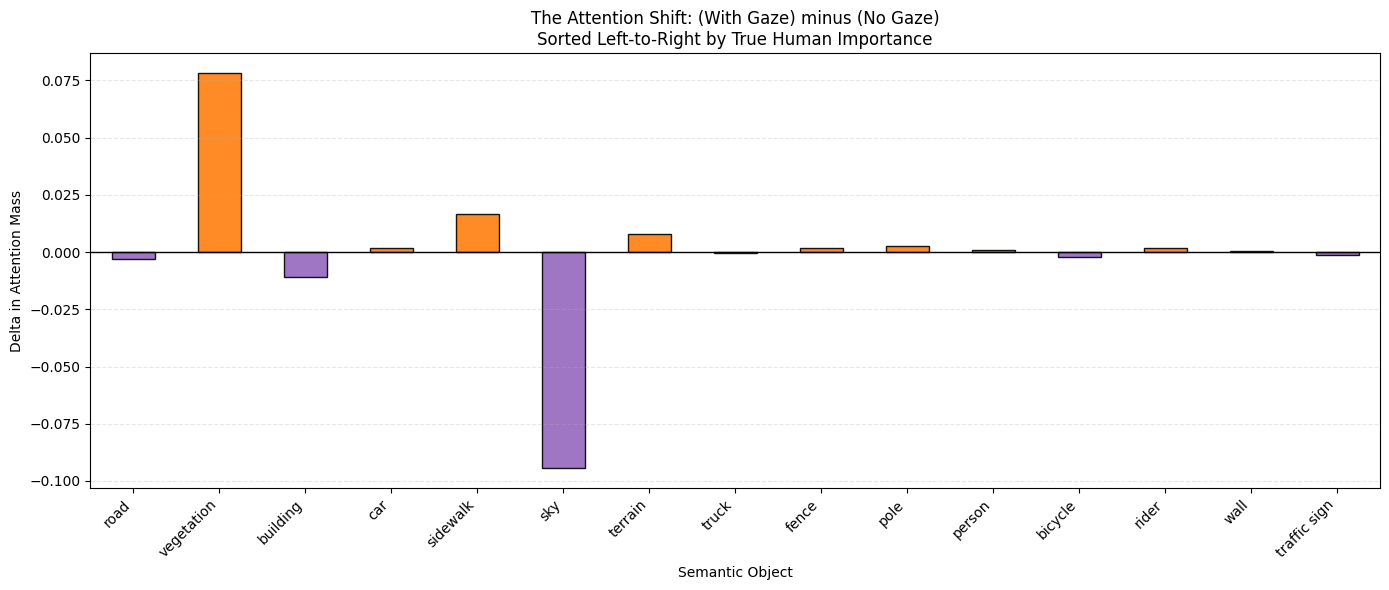

,avg_eye_tracking_mass,avg_no_gaze_mass,avg_with_gaze_mass,shift
road,0.478274,0.473766,0.470892,-0.002874
vegetation,0.137175,0.074531,0.152808,0.078277
building,0.103096,0.107251,0.096530,-0.010722
car,0.069014,0.083860,0.085766,0.001906
sidewalk,0.067771,0.037025,0.053677,0.016651
sky,0.052036,0.145098,0.050717,-0.094381
terrain,0.027941,0.008954,0.016752,0.007798
truck,0.011723,0.007952,0.007760,-0.000192
fence,0.010015,0.011057,0.012782,0.001724
pole,0.009792,0.014069,0.016848,0.002778


In [49]:
# ----------------------------------------------------------------------------
# 9.13) The Correction Shift (Delta Mass)
# ----------------------------------------------------------------------------
# Re-using df_mean_semantic generated in cell 12
if "df_mean_semantic" in globals():
    # Sort objects strictly by human attention mass
    plot_delta = df_mean_semantic.sort_values("avg_eye_tracking_mass", ascending=False).head(15).copy()
    
    # Delta: Positive means "With Gaze" allocates MORE attention than "No Gaze"
    plot_delta["shift"] = plot_delta["avg_with_gaze_mass"] - plot_delta["avg_no_gaze_mass"]
    
    # Colors: Orange if gaze training boosted attention, Purple if it suppressed it
    colors = ['#ff7f0e' if val > 0 else '#9467bd' for val in plot_delta["shift"]]
    
    plt.figure(figsize=(14, 6))
    ax = plot_delta["shift"].plot(
        kind="bar", 
        color=colors, 
        edgecolor='black',
        alpha=0.9
    )
    
    ax.set_title("The Attention Shift: (With Gaze) minus (No Gaze)\nSorted Left-to-Right by True Human Importance")
    ax.set_ylabel("Delta in Attention Mass")
    ax.set_xlabel("Semantic Object")
    
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    display(plot_delta[["avg_eye_tracking_mass", "avg_no_gaze_mass", "avg_with_gaze_mass", "shift"]])
else:
    print("Please ensure df_mean_semantic has been generated (Cell 12) before running this.")

## 10) Dataset object inventory from segmentation masks

Computes per-image object presence and area fractions using `_seg.jpg`, then plots overall frequencies.


In [ ]:

def image_object_inventory(df_rows: pd.DataFrame, max_images: Optional[int] = 2000) -> pd.DataFrame:
    df = df_rows.copy().reset_index(drop=True)

    paths = []
    for side in ("l","r"):
        for _, r in df.iterrows():
            img_path = build_image_path_from_row(r, side)
            seg_path = build_seg_path(img_path)
            paths.append((str(seg_path), str(r["dataset"]), str(img_path.name), side))

    inv = pd.DataFrame(paths, columns=["seg_path","dataset","image_name","side"])
    inv = inv.drop_duplicates(subset=["seg_path"]).copy()

    if max_images is not None and len(inv) > max_images:
        inv = inv.sample(n=int(max_images), random_state=SEED).copy()

    rows = []
    for _, r in inv.iterrows():
        sp = Path(r["seg_path"])
        if not sp.exists():
            continue
        seg = safe_load_rgb(sp)
        flat = seg.reshape(-1, 3)
        uniq, counts = np.unique(flat, axis=0, return_counts=True)
        total = float(counts.sum())

        for color, c in zip(uniq, counts):
            rgb = (int(color[0]), int(color[1]), int(color[2]))
            obj = color_to_object.get(rgb, "unmapped")
            rows.append({
                "seg_path": str(sp),
                "dataset": r["dataset"],
                "image_name": r["image_name"],
                "object": obj,
                "area_frac": float(c) / total if total > 0 else 0.0,
            })

    return pd.DataFrame(rows)

df_inv = image_object_inventory(df_eval_use, max_images=2000)
df_inv.to_csv(OUT_DIR / "dataset_object_inventory.csv", index=False)
print("Saved:", OUT_DIR / "dataset_object_inventory.csv")
df_inv.head()


In [ ]:

if df_inv.empty:
    raise RuntimeError("No inventory rows were generated. Check seg mask existence.")

img_obj = (df_inv.groupby(["image_name","object"], as_index=False)
                .agg(present=("area_frac", lambda x: float((x > 0).any()))))

freq = (img_obj.groupby("object", as_index=False)
              .agg(images=("present","sum"))
              .sort_values("images", ascending=False))

plt.figure(figsize=(10,4))
plt.bar(freq["object"].astype(str).values[:30], freq["images"].values[:30])
plt.xticks(rotation=45, ha="right")
plt.title("Top objects by #images (sampled)")
plt.ylabel("#images")
plt.tight_layout()
plt.show()


## Notes / troubleshooting

- If `color_to_object` ends up tiny:
  - confirm `_seg.jpg` masks exist and align with OGAMA trials,
  - confirm `DISPLAY_SINGLE_W/H` and `RIGHT_X_OFFSET` reflect the stimulus geometry.

- If `df_results` is empty:
  - check `(survey_id, trial_id)` intersection counts,
  - check that attention maps are present in model outputs (`attn_map`).

- If attention maps exist but are all-zero:
  - switch `GLOBAL_ATTN_OVERRIDE["attention_mode"]` between `"raw"` and `"rollout"`,
  - verify the model was built with `use_attn_hook=True` and `return_attn=True`.
